In [60]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import PowerTransformer

from imblearn.combine import SMOTEENN

from pycaret.regression import *
from pycaret.internal.preprocess.transformers import TransformerWrapper
import joblib  # For store the PowerTrasnformers

# Data Innit


In [ ]:
data_24_25 = pd.read_csv('../../merged_player_data.csv')

data_36 = data_24_25[data_24_25['event'] == 36]
data_37 = data_24_25[data_24_25['event'] == 37]
data_38 = data_24_25[data_24_25['event'] == 38]

data_36_gk = data_36[data_36['position'] == 'GK']
data_37_gk = data_37[data_37['position'] == 'GK']
data_38_gk = data_38[data_38['position'] == 'GK']

data_36_def = data_36[data_36['position'] == 'DEF']
data_37_def = data_37[data_37['position'] == 'DEF']
data_38_def = data_38[data_38['position'] == 'DEF']


data_36_mid = data_36[data_36['position'] == 'MID']
data_37_mid = data_37[data_37['position'] == 'MID']
data_38_mid = data_38[data_38['position'] == 'MID']


data_36_fwd = data_36[data_36['position'] == 'FWD']
data_37_fwd = data_37[data_37['position'] == 'FWD']
data_38_fwd = data_38[data_38['position'] == 'FWD']

# Goals


In [ ]:
xg_features = [ 'position',  'xG', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'percenatge_net_transfers', 'ict_index', 'influence', 'creativity', 'threat',

            'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1',  'goals_scored_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1',
            'red_cards_1', 'yellow_cards_1', 'starts_1', 'team_a_score_1', 'team_h_score_1', 'total_points_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1', 'assists_x_1', 'assists_y_1',
            'key_passes_1', 'npg_1', 'npxG_1', 'xGChain_1', 'xGBuildup_1',  'xP_1',

            'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3',  'goals_scored_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3',
            'red_cards_3', 'yellow_cards_3', 'starts_3', 'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_x_3', 'assists_y_3',
            'key_passes_3', 'npg_3', 'npxG_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5',  'goals_scored_5', 'ict_index_5', 'influence_5', 'creativity_5', 'threat_5', 'minutes_5',
            'red_cards_5', 'yellow_cards_5', 'starts_5', 'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_x_5', 'assists_y_5',
            'key_passes_5', 'npg_5', 'npxG_5', 'xGChain_5', 'xGBuildup_5',  'xP_5'
]

## DEF


In [70]:
data_36_def_xg = data_36_def[xg_features]
data_37_def_xg = data_37_def[xg_features]
data_38_def_xg = data_38_def[xg_features]

# Load model
def_xg_model = load_model('../def_xg_final_model')
pt_def_xg = joblib.load('../pt_def_xg.pkl')  # Load fitted transformer

Transformation Pipeline and Model Successfully Loaded


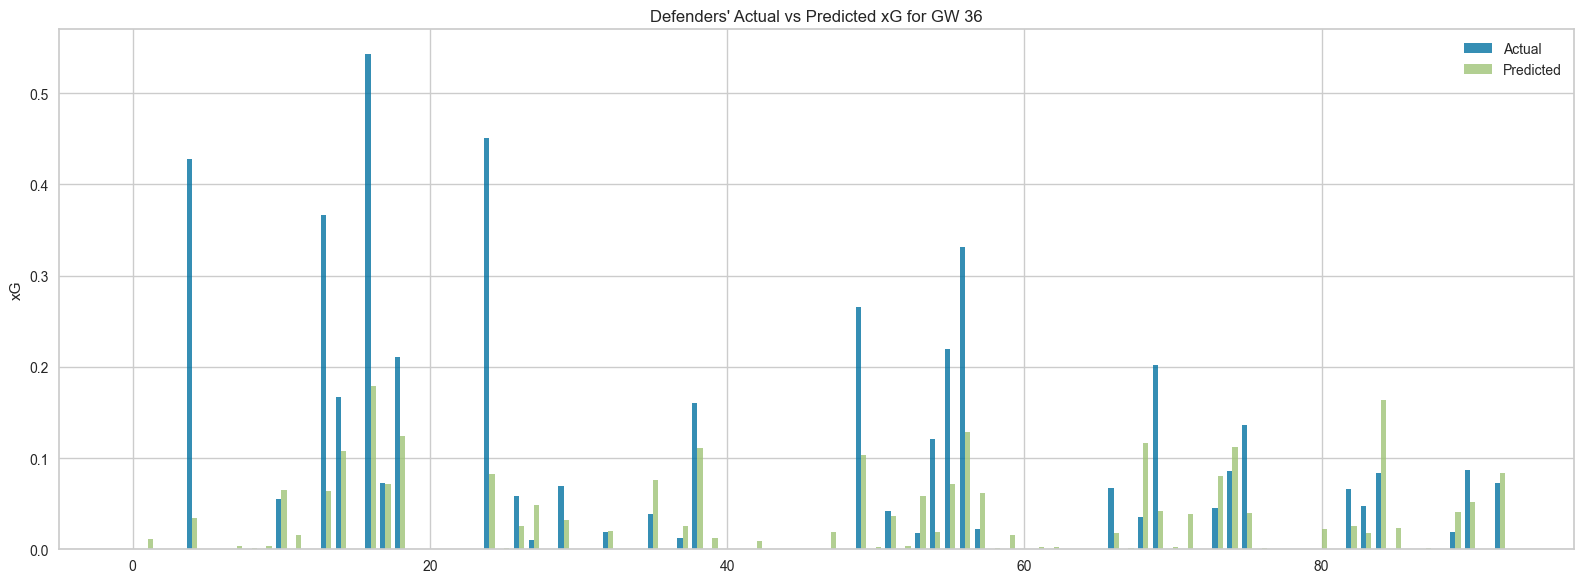

In [71]:
def_xg = data_36_def_xg[['xG']].copy()
data_36_def_xg.drop(columns=['position', 'xG'], inplace=True)

def_xg_preds_36 = predict_model(def_xg_model, data=data_36_def_xg)
def_xg_preds_36 = def_xg_preds_36.rename(columns={'prediction_label': 'xG_preds_trans'})

actual = def_xg['xG']
predicted = pt_def_xg.inverse_transform(def_xg_preds_36[['xG_preds_trans']].rename(columns={'xG_preds_trans': 'xG'}))

# Add predicted to data_36_def
data_36_def['xG_preds'] = predicted



# Bar plot side-by-side
x = np.arange(len(actual))
width = 0.35

# print
plt.figure(figsize=(16, 6))
plt.bar(x - width/2, actual, width, label='Actual', alpha=0.8)
plt.bar(x + width/2, predicted.flatten(), width, label='Predicted', alpha=0.8)

# plt.xticks(x, players, rotation=90)
plt.ylabel('xG')
plt.title("Defenders' Actual vs Predicted xG for GW 36")
plt.legend()
plt.tight_layout()
plt.show()


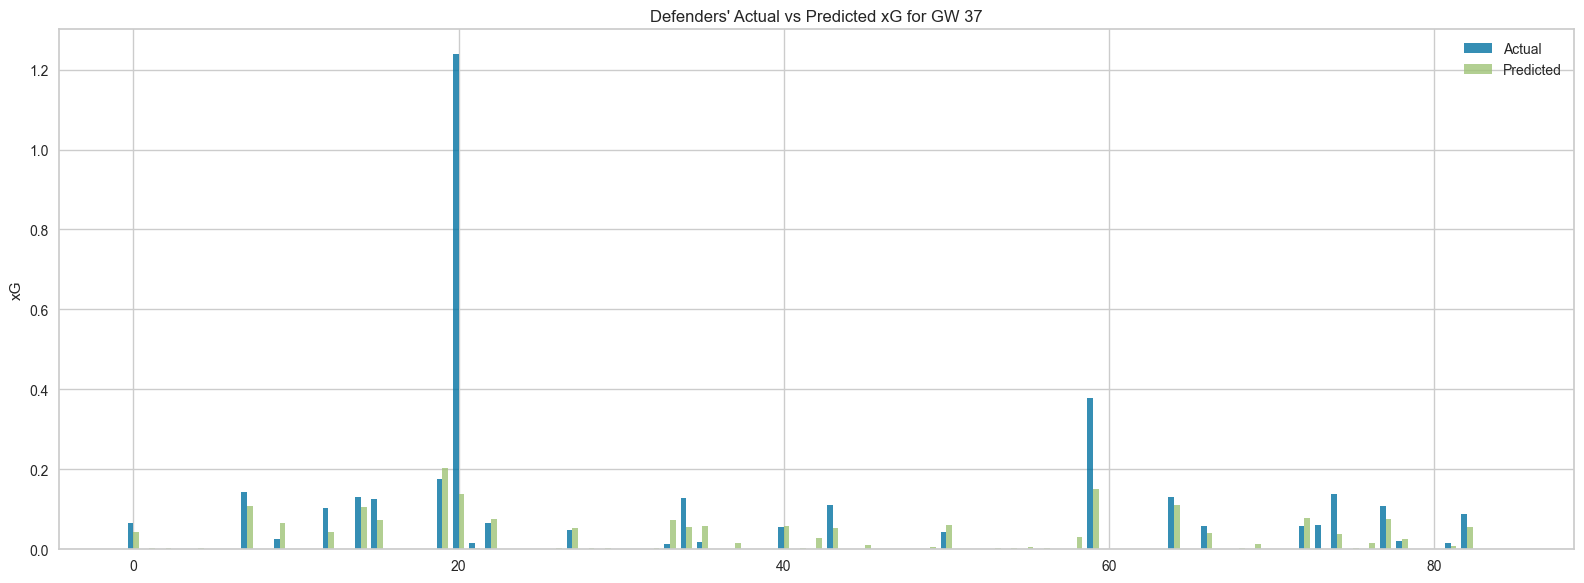

In [72]:
# data_37_def_xg.reset_index(drop=True, inplace=True)
def_xg = data_37_def_xg[['xG']].copy()
data_37_def_xg.drop(columns=['position', 'xG'], inplace=True)

def_xg_preds_37 = predict_model(def_xg_model, data=data_37_def_xg)
def_xg_preds_37 = def_xg_preds_37.rename(columns={'prediction_label': 'xG_preds_trans'})

actual = def_xg['xG']
predicted = pt_def_xg.inverse_transform(def_xg_preds_37[['xG_preds_trans']].rename(columns={'xG_preds_trans': 'xG'}))

# Add predicted to data_37_def
data_37_def['xG_preds'] = predicted

# Bar plot side-by-side
x = np.arange(len(actual))
width = 0.35

# print
plt.figure(figsize=(16, 6))
plt.bar(x - width/2, actual, width, label='Actual', alpha=0.8)
plt.bar(x + width/2, predicted.flatten(), width, label='Predicted', alpha=0.8)

# plt.xticks(x, players, rotation=90)
plt.ylabel('xG')
plt.title("Defenders' Actual vs Predicted xG for GW 37")
plt.legend()
plt.tight_layout()
plt.show()


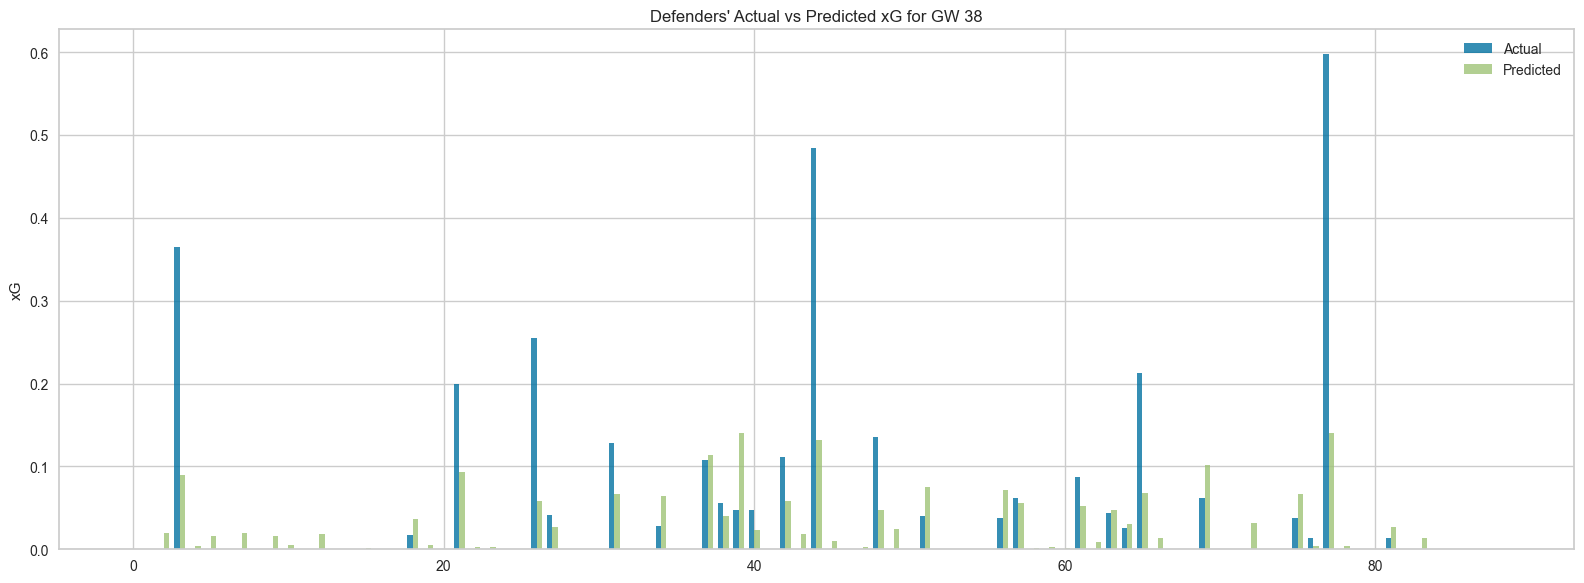

In [73]:
# data_38_def_xg.reset_index(drop=True, inplace=True)
def_xg = data_38_def_xg[['xG']].copy()
data_38_def_xg.drop(columns=['position', 'xG'], inplace=True)

def_xg_preds_38 = predict_model(def_xg_model, data=data_38_def_xg)
def_xg_preds_38 = def_xg_preds_38.rename(columns={'prediction_label': 'xG_preds_trans'})

actual = def_xg['xG']
predicted = pt_def_xg.inverse_transform(def_xg_preds_38[['xG_preds_trans']].rename(columns={'xG_preds_trans': 'xG'}))

# Add predicted to data_38_def
data_38_def['xG_preds'] = predicted

# Bar plot side-by-side
x = np.arange(len(actual))
width = 0.35

# print
plt.figure(figsize=(16, 6))
plt.bar(x - width/2, actual, width, label='Actual', alpha=0.8)
plt.bar(x + width/2, predicted.flatten(), width, label='Predicted', alpha=0.8)

# plt.xticks(x, players, rotation=90)
plt.ylabel('xG')
plt.title("Defenders' Actual vs Predicted xG for GW 38")
plt.legend()
plt.tight_layout()
plt.show()


## MID


In [74]:
data_36_mid_xg = data_36_mid[xg_features]
data_37_mid_xg = data_37_mid[xg_features]
data_38_mid_xg = data_38_mid[xg_features]

# Load model
mid_xg_model = load_model('../mid_xg_final_model')
pt_mid_xg = joblib.load('../pt_mid_xg.pkl')  # Load fitted transformer


Transformation Pipeline and Model Successfully Loaded


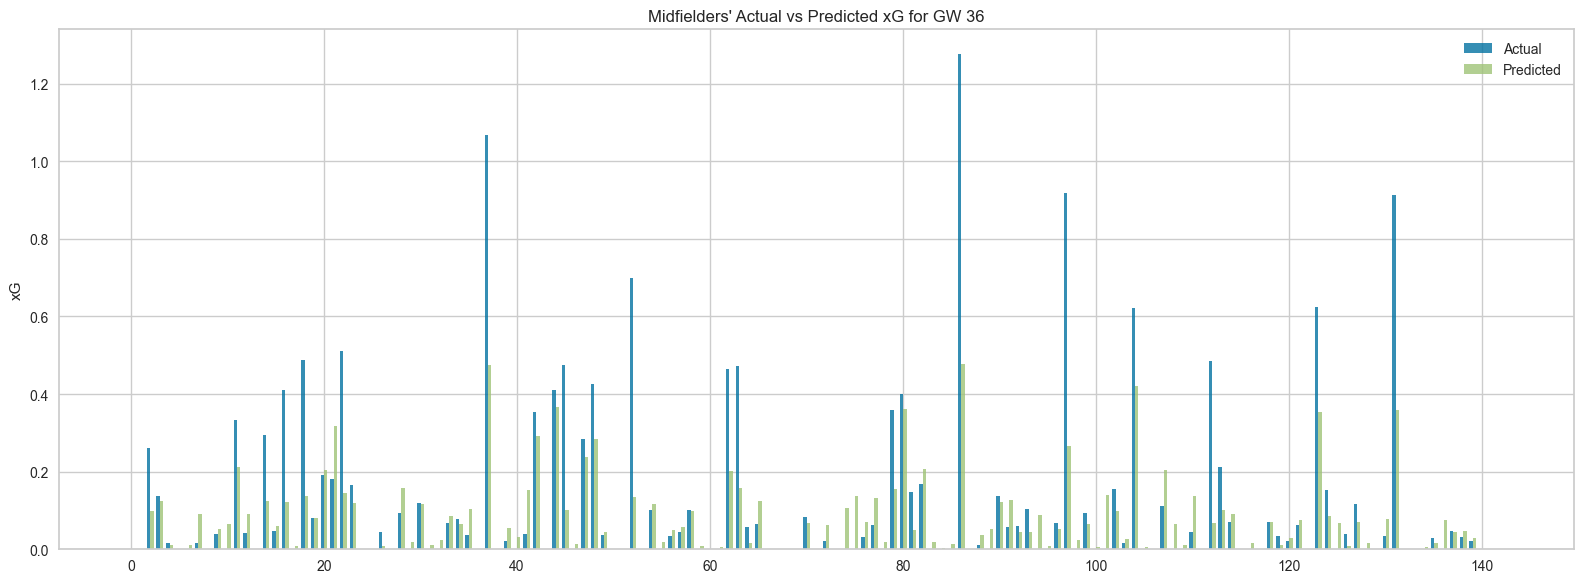

In [75]:
mid_xg = data_36_mid_xg[['xG']].copy()
data_36_mid_xg.drop(columns=['position', 'xG'], inplace=True)

mid_xg_preds_36 = predict_model(mid_xg_model, data=data_36_mid_xg)
mid_xg_preds_36 = mid_xg_preds_36.rename(columns={'prediction_label': 'xG_preds_trans'})

actual = mid_xg['xG']
predicted = pt_mid_xg.inverse_transform(mid_xg_preds_36[['xG_preds_trans']].rename(columns={'xG_preds_trans': 'xG'}))

# Add predicted to data_36_mid
data_36_mid['xG_preds'] = predicted

# Bar plot side-by-side
x = np.arange(len(actual))
width = 0.35

# print
plt.figure(figsize=(16, 6))
plt.bar(x - width/2, actual, width, label='Actual', alpha=0.8)
plt.bar(x + width/2, predicted.flatten(), width, label='Predicted', alpha=0.8)

# plt.xticks(x, players, rotation=90)
plt.ylabel('xG')
plt.title("Midfielders' Actual vs Predicted xG for GW 36")
plt.legend()
plt.tight_layout()
plt.show()


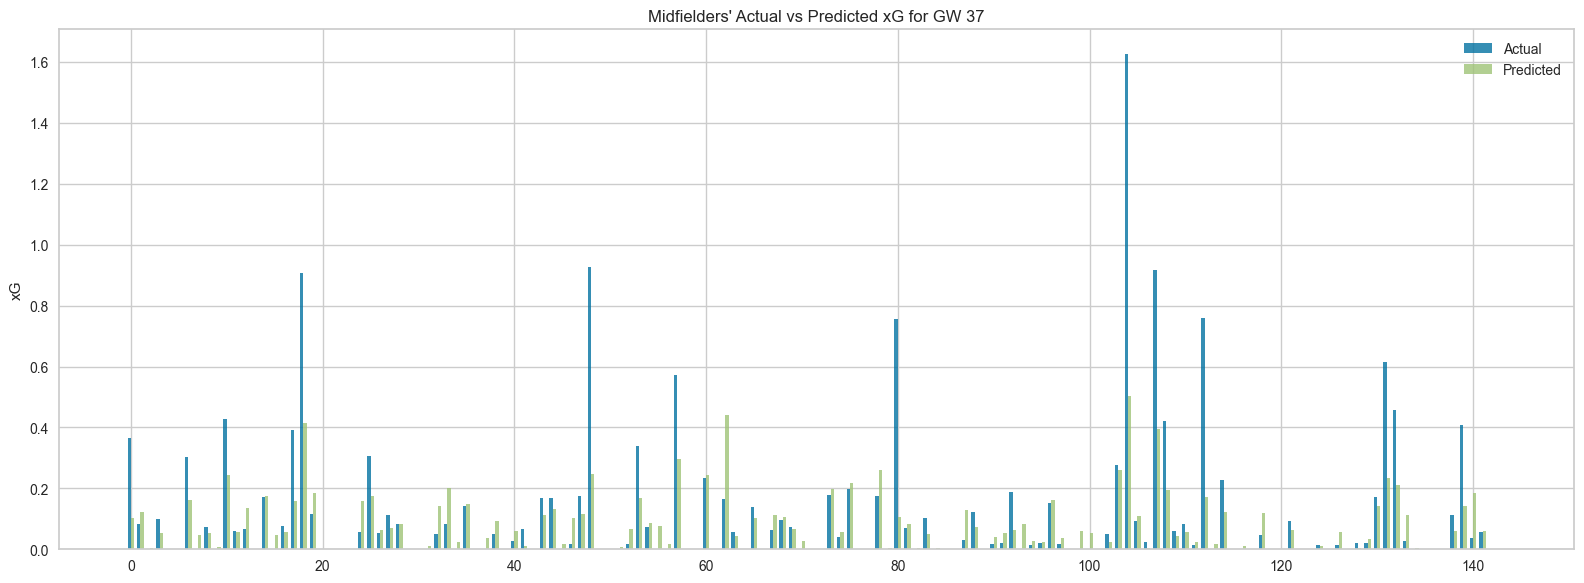

In [76]:
# data_37_mid_xg.reset_index(drop=True, inplace=True)
mid_xg = data_37_mid_xg[['xG']].copy()
data_37_mid_xg.drop(columns=['position', 'xG'], inplace=True)

mid_xg_preds_37 = predict_model(mid_xg_model, data=data_37_mid_xg)
mid_xg_preds_37 = mid_xg_preds_37.rename(columns={'prediction_label': 'xG_preds_trans'})

actual = mid_xg['xG']
predicted = pt_mid_xg.inverse_transform(mid_xg_preds_37[['xG_preds_trans']].rename(columns={'xG_preds_trans': 'xG'}))

# Add predicted to data_37_mid
data_37_mid['xG_preds'] = predicted

# Bar plot side-by-side
x = np.arange(len(actual))
width = 0.35

# print
plt.figure(figsize=(16, 6))
plt.bar(x - width/2, actual, width, label='Actual', alpha=0.8)
plt.bar(x + width/2, predicted.flatten(), width, label='Predicted', alpha=0.8)

# plt.xticks(x, players, rotation=90)
plt.ylabel('xG')
plt.title("Midfielders' Actual vs Predicted xG for GW 37")
plt.legend()
plt.tight_layout()
plt.show()


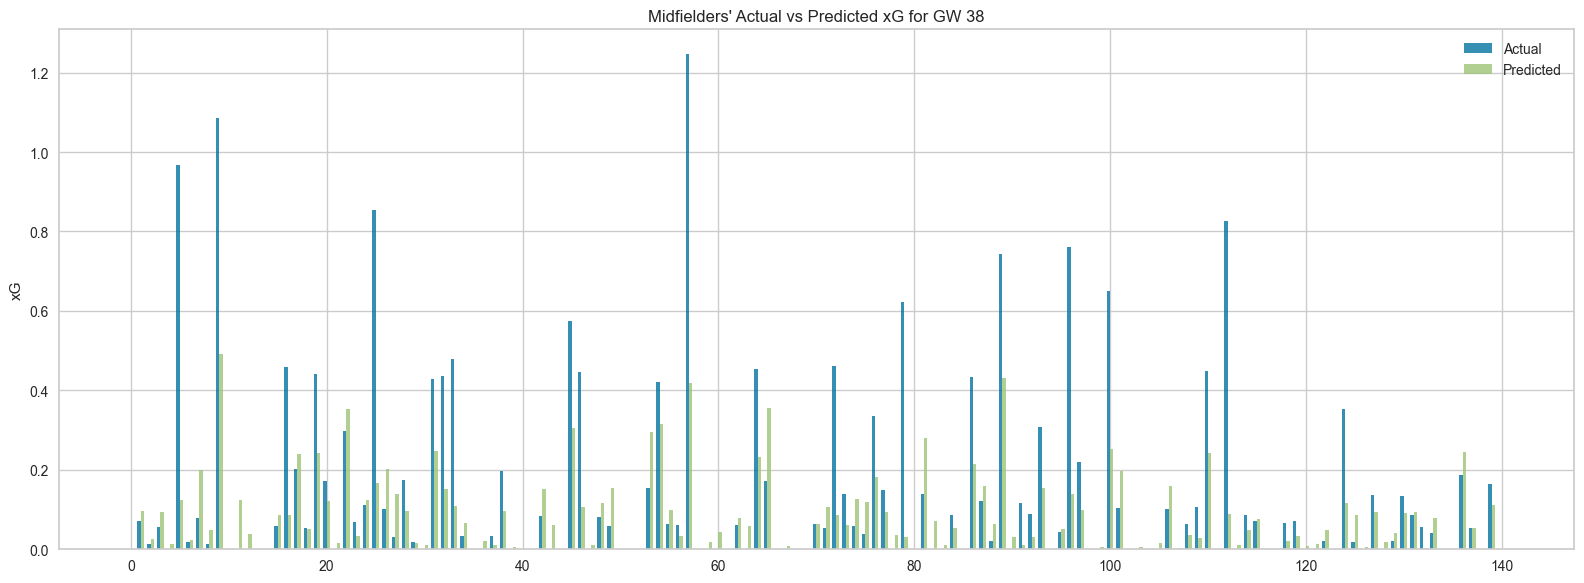

In [77]:
# data_38_mid_xg.reset_index(drop=True, inplace=True)
mid_xg = data_38_mid_xg[['xG']].copy()
data_38_mid_xg.drop(columns=['position', 'xG'], inplace=True)

mid_xg_preds_38 = predict_model(mid_xg_model, data=data_38_mid_xg)
mid_xg_preds_38 = mid_xg_preds_38.rename(columns={'prediction_label': 'xG_preds_trans'})

actual = mid_xg['xG']
predicted = pt_mid_xg.inverse_transform(mid_xg_preds_38[['xG_preds_trans']].rename(columns={'xG_preds_trans': 'xG'}))

# Add predicted to data_38_mid
data_38_mid['xG_preds'] = predicted

# Bar plot side-by-side
x = np.arange(len(actual))
width = 0.35

# print
plt.figure(figsize=(16, 6))
plt.bar(x - width/2, actual, width, label='Actual', alpha=0.8)
plt.bar(x + width/2, predicted.flatten(), width, label='Predicted', alpha=0.8)

# plt.xticks(x, players, rotation=90)
plt.ylabel('xG')
plt.title("Midfielders' Actual vs Predicted xG for GW 38")
plt.legend()
plt.tight_layout()
plt.show()


## FWD


In [78]:
data_36_fwd_xg = data_36_fwd[xg_features]
data_37_fwd_xg = data_37_fwd[xg_features]
data_38_fwd_xg = data_38_fwd[xg_features]

# Load model
fwd_xg_model = load_model('../fwd_xg_final_model')
pt_fwd_xg = joblib.load('../pt_fwd_xg.pkl')  # Load fitted transformer


Transformation Pipeline and Model Successfully Loaded


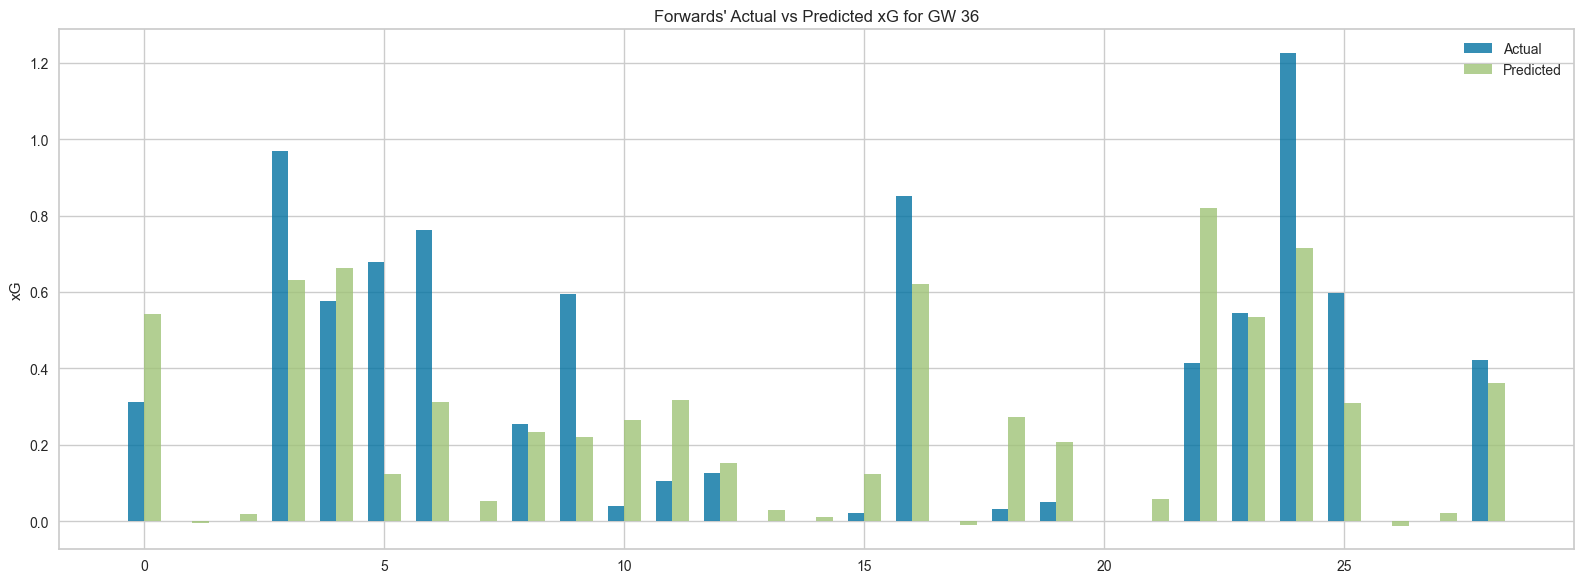

In [79]:
# data_36_fwd_xg.reset_index(drop=True, inplace=True)
fwd_xg = data_36_fwd_xg[['xG']].copy()
data_36_fwd_xg.drop(columns=['position', 'xG'], inplace=True)

fwd_xg_preds_36 = predict_model(fwd_xg_model, data=data_36_fwd_xg)
fwd_xg_preds_36 = fwd_xg_preds_36.rename(columns={'prediction_label': 'xG_preds_trans'})

actual = fwd_xg['xG']
predicted = pt_fwd_xg.inverse_transform(fwd_xg_preds_36[['xG_preds_trans']].rename(columns={'xG_preds_trans': 'xG'}))

# Add predicted to data_36_fwd
data_36_fwd['xG_preds'] = predicted

# Bar plot side-by-side
x = np.arange(len(actual))
width = 0.35

# print
plt.figure(figsize=(16, 6))
plt.bar(x - width/2, actual, width, label='Actual', alpha=0.8)
plt.bar(x + width/2, predicted.flatten(), width, label='Predicted', alpha=0.8)

# plt.xticks(x, players, rotation=90)
plt.ylabel('xG')
plt.title("Forwards' Actual vs Predicted xG for GW 36")
plt.legend()
plt.tight_layout()
plt.show()


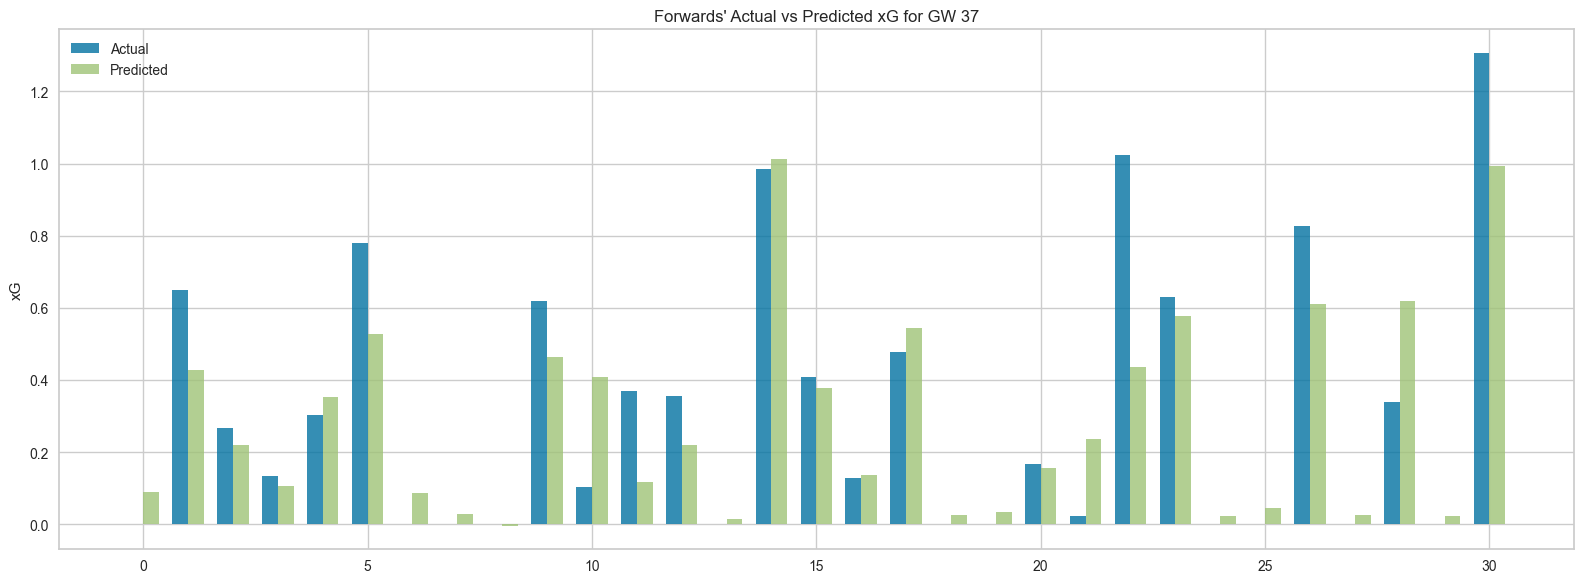

In [80]:
# data_37_fwd_xg.reset_index(drop=True, inplace=True)
fwd_xg = data_37_fwd_xg[['xG']].copy()
data_37_fwd_xg.drop(columns=['position', 'xG'], inplace=True)

fwd_xg_preds_37 = predict_model(fwd_xg_model, data=data_37_fwd_xg)
fwd_xg_preds_37 = fwd_xg_preds_37.rename(columns={'prediction_label': 'xG_preds_trans'})

actual = fwd_xg['xG']
predicted = pt_fwd_xg.inverse_transform(fwd_xg_preds_37[['xG_preds_trans']].rename(columns={'xG_preds_trans': 'xG'}))

# Add predicted to data_37_fwd
data_37_fwd['xG_preds'] = predicted

# Bar plot side-by-side
x = np.arange(len(actual))
width = 0.35

# print
plt.figure(figsize=(16, 6))
plt.bar(x - width/2, actual, width, label='Actual', alpha=0.8)
plt.bar(x + width/2, predicted.flatten(), width, label='Predicted', alpha=0.8)

# plt.xticks(x, players, rotation=90)
plt.ylabel('xG')
plt.title("Forwards' Actual vs Predicted xG for GW 37")
plt.legend()
plt.tight_layout()
plt.show()


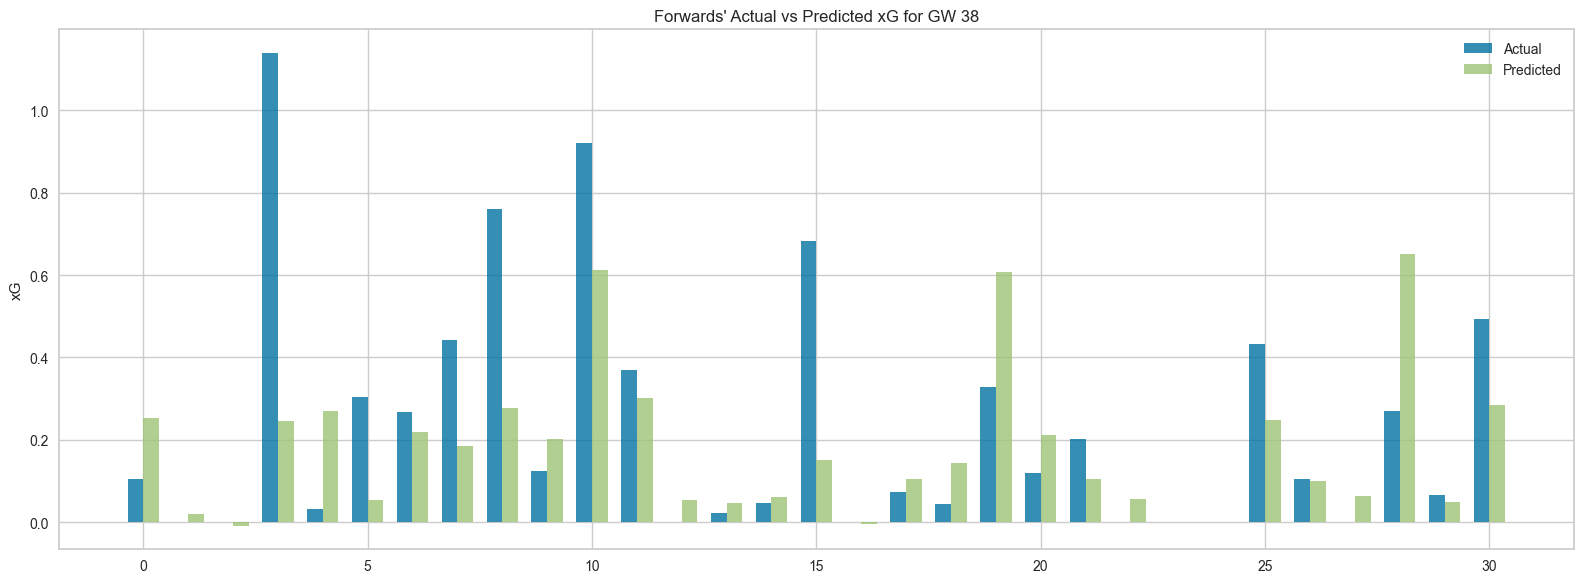

In [81]:
# data_38_fwd_xg.reset_index(drop=True, inplace=True)
fwd_xg = data_38_fwd_xg[['xG']].copy()
data_38_fwd_xg.drop(columns=['position', 'xG'], inplace=True)

fwd_xg_preds_38 = predict_model(fwd_xg_model, data=data_38_fwd_xg)
fwd_xg_preds_38 = fwd_xg_preds_38.rename(columns={'prediction_label': 'xG_preds_trans'})

actual = fwd_xg['xG']
predicted = pt_fwd_xg.inverse_transform(fwd_xg_preds_38[['xG_preds_trans']].rename(columns={'xG_preds_trans': 'xG'}))

# Add predicted to data_38_fwd
data_38_fwd['xG_preds'] = predicted


# Bar plot side-by-side
x = np.arange(len(actual))
width = 0.35

# print
plt.figure(figsize=(16, 6))
plt.bar(x - width/2, actual, width, label='Actual', alpha=0.8)
plt.bar(x + width/2, predicted.flatten(), width, label='Predicted', alpha=0.8)

# plt.xticks(x, players, rotation=90)
plt.ylabel('xG')
plt.title("Forwards' Actual vs Predicted xG for GW 38")
plt.legend()
plt.tight_layout()
plt.show()


# Assists


In [ ]:
xa_features = [ 'position',  'xA', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'percenatge_net_transfers', 'ict_index', 'influence',
                 'creativity', 'threat','starts',

            'expected_assists_1', 'expected_goal_involvements_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1',
            'red_cards_1', 'yellow_cards_1', 'starts_1', 'team_a_score_1', 'team_h_score_1', 'total_points_1',  'shots_1','xA_1', 'assists_x_1', 'assists_y_1',
            'key_passes_1', 'xGChain_1', 'xGBuildup_1',  'xP_1',

            'expected_assists_3', 'expected_goal_involvements_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3',
            'red_cards_3', 'yellow_cards_3', 'starts_3', 'team_a_score_3', 'team_h_score_3', 'total_points_3', 'shots_3', 'xA_3', 'assists_x_3', 'assists_y_3',
            'key_passes_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'expected_assists_5', 'expected_goal_involvements_5', 'ict_index_5', 'influence_5', 'creativity_5', 'threat_5', 'minutes_5',
            'red_cards_5', 'yellow_cards_5', 'starts_5', 'team_a_score_5', 'team_h_score_5', 'total_points_5', 'shots_5',  'xA_5', 'assists_x_5', 'assists_y_5',
            'key_passes_5', 'xGChain_5', 'xGBuildup_5',  'xP_5'
]

## DEF


In [ ]:
data_36_def_xa = data_36_def[xa_features]
data_37_def_xa = data_37_def[xa_features]
data_38_def_xa = data_38_def[xa_features]

# Load model
def_xa_model = load_model('../def_xa_final_model')
pt_def_xa = joblib.load('../pt_def_xa.pkl')  # Load fitted transformer

Transformation Pipeline and Model Successfully Loaded


In [ ]:
def_xa = data_36_def_xa[['xA']].copy()
data_36_def_xa.drop(columns=['position', 'xA'], inplace=True)

def_xa_preds_36 = predict_model(def_xa_model, data=data_36_def_xa)
def_xa_preds_36 = def_xa_preds_36.rename(columns={'prediction_label': 'xA_preds_trans'})

actual = def_xa['xA']
predicted = pt_def_xa.inverse_transform(def_xa_preds_36[['xA_preds_trans']].rename(columns={'xA_preds_trans': 'xA'}))

# Add predicted to data_36_def
data_36_def['xA_preds'] = predicted

# Bar plot side-by-side
x = np.arange(len(actual))
width = 0.35

# print
plt.figure(figsize=(16, 6))
plt.bar(x - width/2, actual, width, label='Actual', alpha=0.8)
plt.bar(x + width/2, predicted.flatten(), width, label='Predicted', alpha=0.8)

# plt.xticks(x, players, rotation=90)
plt.ylabel('xA')
plt.title("Defenders' Actual vs Predicted xA for GW 36")
plt.legend()
plt.tight_layout()
plt.show()


KeyError: "['ownership_change', 'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'own_goals_1', 'penalties_saved_1', 'saves_1', 'clean_sheets_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'own_goals_2', 'penalties_saved_2', 'saves_2', 'clean_sheets_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'own_goals_3', 'penalties_saved_3', 'saves_3', 'clean_sheets_4', 'expected_goals_conceded_4', 'goals_conceded_4', 'own_goals_4', 'penalties_saved_4', 'saves_4', 'clean_sheets_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'own_goals_5', 'penalties_saved_5', 'saves_5'] not in index"

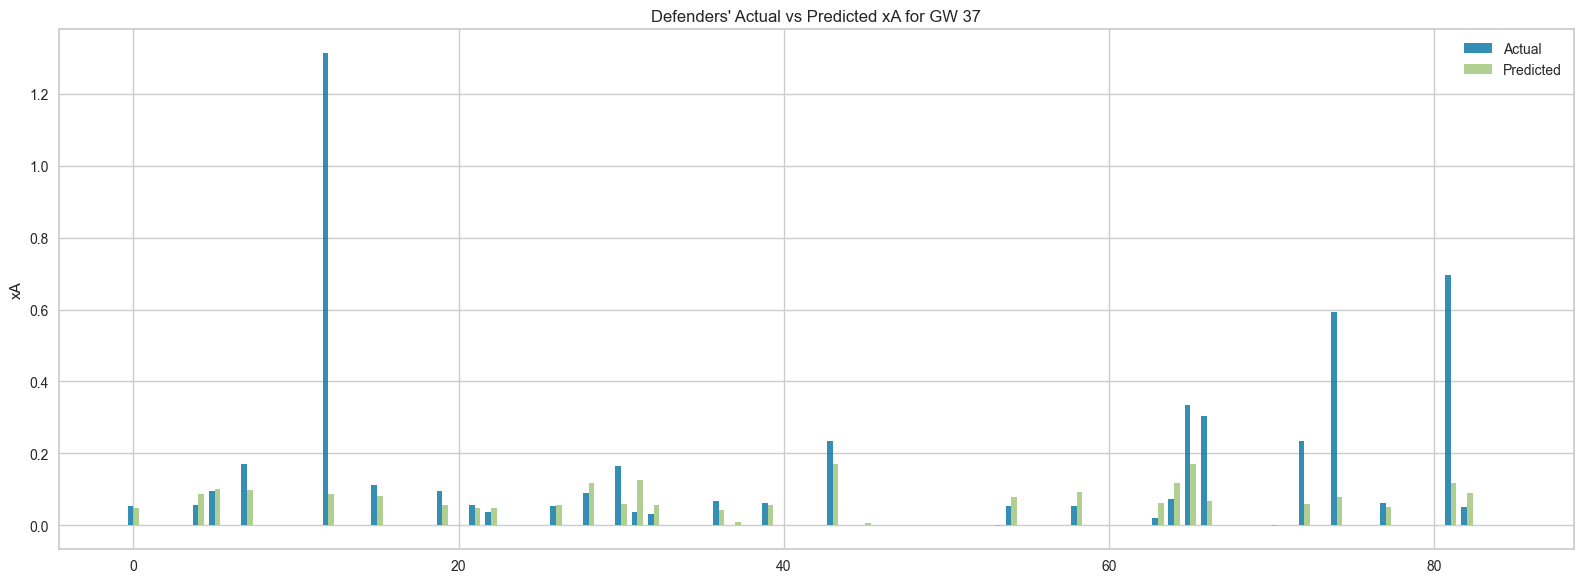

In [ ]:
# data_37_def_xa.reset_index(drop=True, inplace=True)
def_xa = data_37_def_xa[['xA']].copy()
data_37_def_xa.drop(columns=['position', 'xA'], inplace=True)

def_xa_preds_37 = predict_model(def_xa_model, data=data_37_def_xa)
def_xa_preds_37 = def_xa_preds_37.rename(columns={'prediction_label': 'xA_preds_trans'})

actual = def_xa['xA']
predicted = pt_def_xa.inverse_transform(def_xa_preds_37[['xA_preds_trans']].rename(columns={'xA_preds_trans': 'xA'}))

# Add predicted to data_37_def
data_37_def['xA_preds'] = predicted

# Bar plot side-by-side
x = np.arange(len(actual))
width = 0.35

# print
plt.figure(figsize=(16, 6))
plt.bar(x - width/2, actual, width, label='Actual', alpha=0.8)
plt.bar(x + width/2, predicted.flatten(), width, label='Predicted', alpha=0.8)

# plt.xticks(x, players, rotation=90)
plt.ylabel('xA')
plt.title("Defenders' Actual vs Predicted xA for GW 37")
plt.legend()
plt.tight_layout()
plt.show()


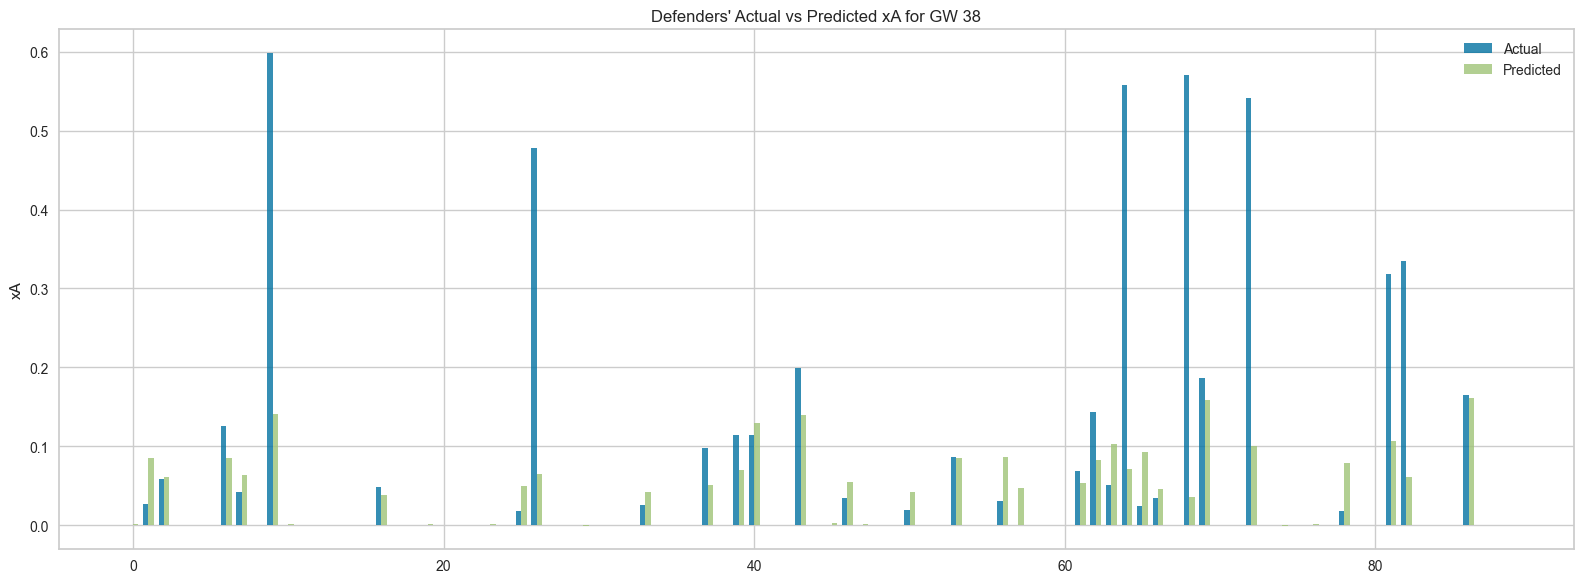

In [ ]:
# data_38_def_xa.reset_index(drop=True, inplace=True)
def_xa = data_38_def_xa[['xA']].copy()
data_38_def_xa.drop(columns=['position', 'xA'], inplace=True)

def_xa_preds_38 = predict_model(def_xa_model, data=data_38_def_xa)
def_xa_preds_38 = def_xa_preds_38.rename(columns={'prediction_label': 'xA_preds_trans'})

actual = def_xa['xA']
predicted = pt_def_xa.inverse_transform(def_xa_preds_38[['xA_preds_trans']].rename(columns={'xA_preds_trans': 'xA'}))

# Add predicted to data_38_def
data_38_def['xA_preds'] = predicted

# Bar plot side-by-side
x = np.arange(len(actual))
width = 0.35

# print
plt.figure(figsize=(16, 6))
plt.bar(x - width/2, actual, width, label='Actual', alpha=0.8)
plt.bar(x + width/2, predicted.flatten(), width, label='Predicted', alpha=0.8)

# plt.xticks(x, players, rotation=90)
plt.ylabel('xA')
plt.title("Defenders' Actual vs Predicted xA for GW 38")
plt.legend()
plt.tight_layout()
plt.show()


## MID


In [ ]:
data_36_mid_xa = data_36_mid[xa_features]
data_37_mid_xa = data_37_mid[xa_features]
data_38_mid_xa = data_38_mid[xa_features]

# Load model
mid_xa_model = load_model('../mid_xa_final_model')
pt_mid_xa = joblib.load('../pt_mid_xa.pkl')  # Load fitted transformer

Transformation Pipeline and Model Successfully Loaded


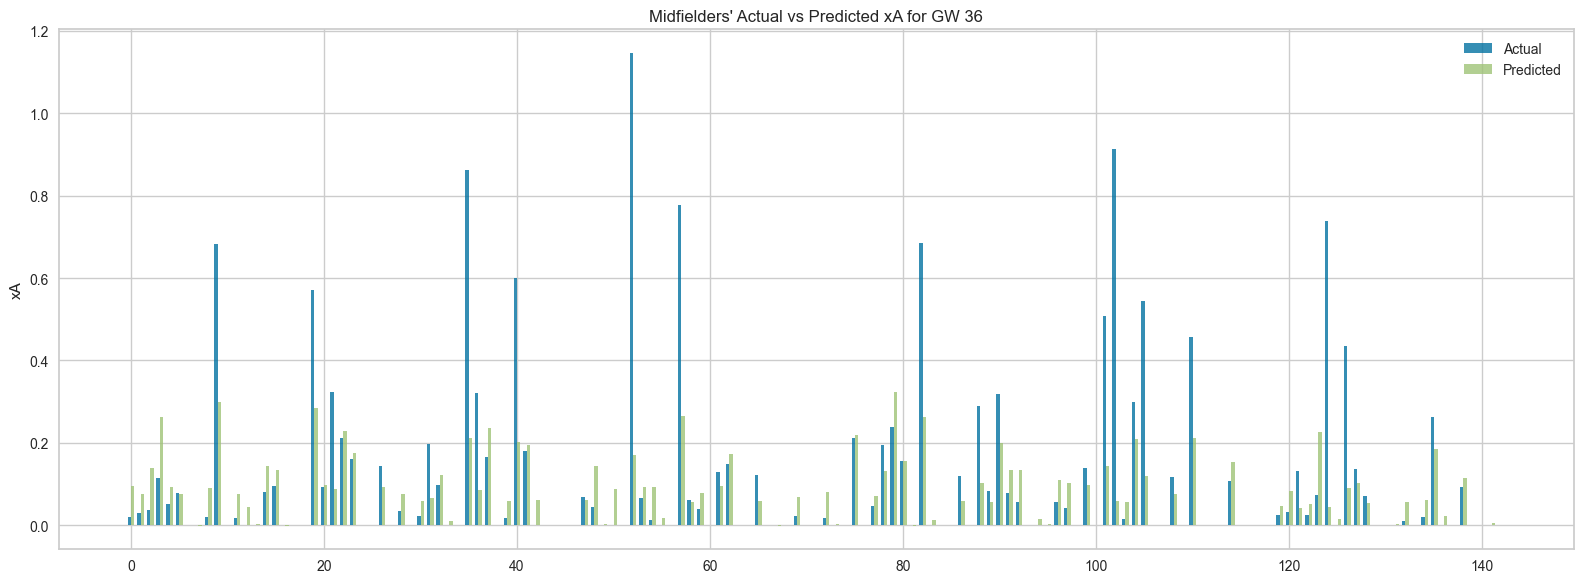

In [ ]:
# data_36_mid_xa.reset_index(drop=True, inplace=True)
mid_xa = data_36_mid_xa[['xA']].copy()
data_36_mid_xa.drop(columns=['position', 'xA'], inplace=True)

mid_xa_preds_36 = predict_model(mid_xa_model, data=data_36_mid_xa)
mid_xa_preds_36 = mid_xa_preds_36.rename(columns={'prediction_label': 'xA_preds_trans'})

actual = mid_xa['xA']
predicted = pt_mid_xa.inverse_transform(mid_xa_preds_36[['xA_preds_trans']].rename(columns={'xA_preds_trans': 'xA'}))

# Add predicted to data_36_mid
data_36_mid['xA_preds'] = predicted

# Bar plot side-by-side
x = np.arange(len(actual))
width = 0.35

# print
plt.figure(figsize=(16, 6))
plt.bar(x - width/2, actual, width, label='Actual', alpha=0.8)
plt.bar(x + width/2, predicted.flatten(), width, label='Predicted', alpha=0.8)

# plt.xticks(x, players, rotation=90)
plt.ylabel('xA')
plt.title("Midfielders' Actual vs Predicted xA for GW 36")
plt.legend()
plt.tight_layout()
plt.show()


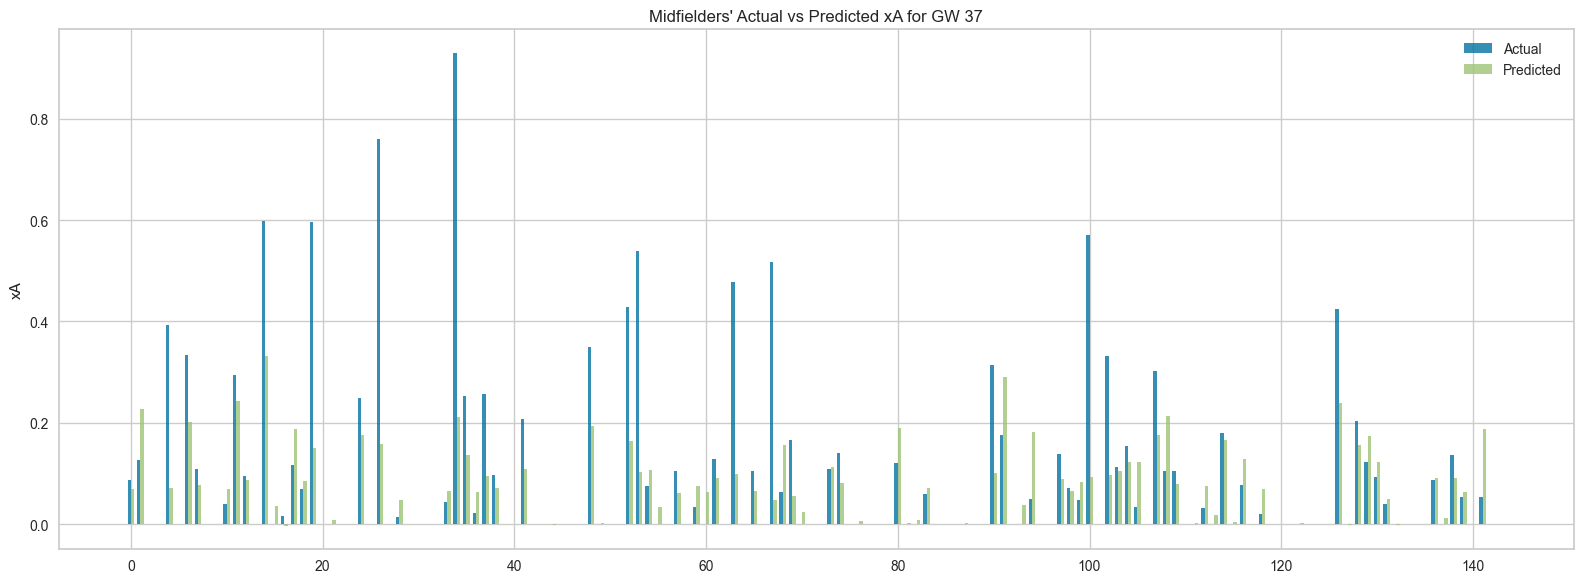

In [ ]:
# data_37_mid_xa.reset_index(drop=True, inplace=True)
mid_xa = data_37_mid_xa[['xA']].copy()
data_37_mid_xa.drop(columns=['position', 'xA'], inplace=True)

mid_xa_preds_37 = predict_model(mid_xa_model, data=data_37_mid_xa)
mid_xa_preds_37 = mid_xa_preds_37.rename(columns={'prediction_label': 'xA_preds_trans'})

actual = mid_xa['xA']
predicted = pt_mid_xa.inverse_transform(mid_xa_preds_37[['xA_preds_trans']].rename(columns={'xA_preds_trans': 'xA'}))

# Add predicted to data_37_mid
data_37_mid['xA_preds'] = predicted

# Bar plot side-by-side
x = np.arange(len(actual))
width = 0.35

# print
plt.figure(figsize=(16, 6))
plt.bar(x - width/2, actual, width, label='Actual', alpha=0.8)
plt.bar(x + width/2, predicted.flatten(), width, label='Predicted', alpha=0.8)

# plt.xticks(x, players, rotation=90)
plt.ylabel('xA')
plt.title("Midfielders' Actual vs Predicted xA for GW 37")
plt.legend()
plt.tight_layout()
plt.show()


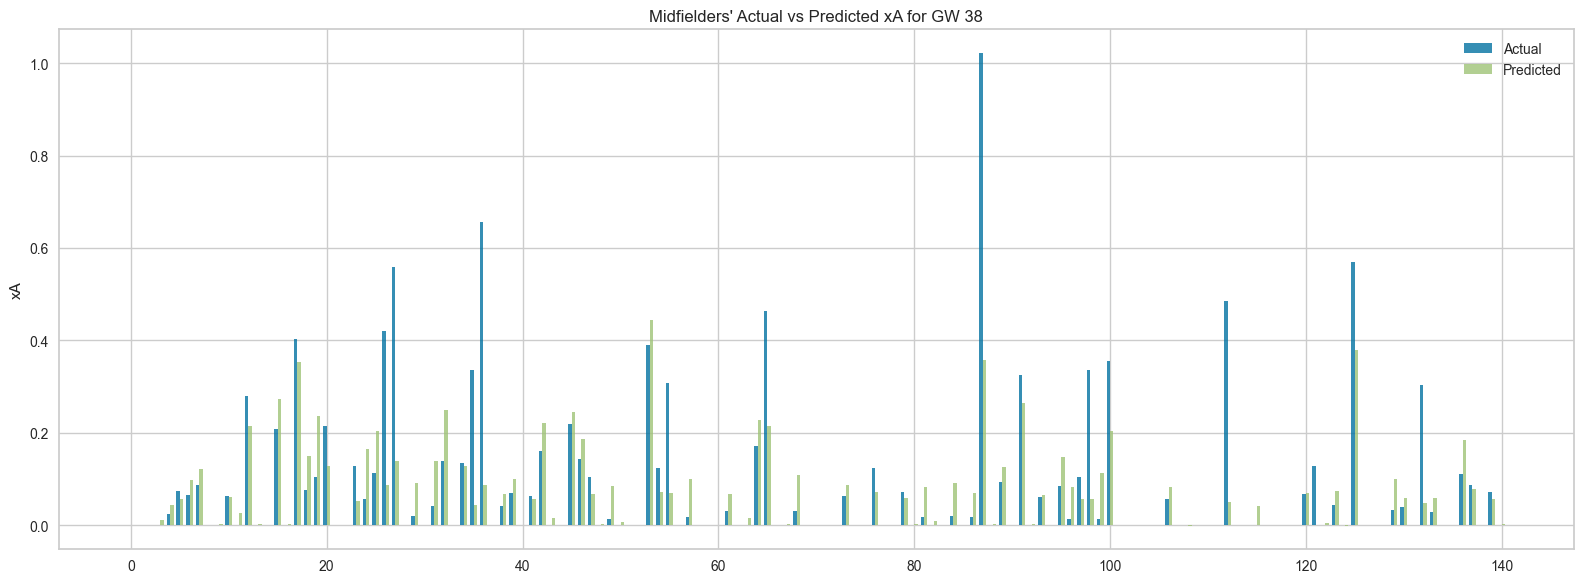

In [ ]:
# data_38_mid_xa.reset_index(drop=True, inplace=True)
mid_xa = data_38_mid_xa[['xA']].copy()
data_38_mid_xa.drop(columns=['position', 'xA'], inplace=True)

mid_xa_preds_38 = predict_model(mid_xa_model, data=data_38_mid_xa)
mid_xa_preds_38 = mid_xa_preds_38.rename(columns={'prediction_label': 'xA_preds_trans'})

actual = mid_xa['xA']
predicted = pt_mid_xa.inverse_transform(mid_xa_preds_38[['xA_preds_trans']].rename(columns={'xA_preds_trans': 'xA'}))

# Add predicted to data_38_mid
data_38_mid['xA_preds'] = predicted

# Bar plot side-by-side
x = np.arange(len(actual))
width = 0.35

# print
plt.figure(figsize=(16, 6))
plt.bar(x - width/2, actual, width, label='Actual', alpha=0.8)
plt.bar(x + width/2, predicted.flatten(), width, label='Predicted', alpha=0.8)

# plt.xticks(x, players, rotation=90)
plt.ylabel('xA')
plt.title("Midfielders' Actual vs Predicted xA for GW 38")
plt.legend()
plt.tight_layout()
plt.show()


## FWD


In [ ]:
data_36_fwd_xa = data_36_fwd[xa_features]
data_37_fwd_xa = data_37_fwd[xa_features]
data_38_fwd_xa = data_38_fwd[xa_features]

# Load model
fwd_xa_model = load_model('../fwd_xa_final_model')
pt_fwd_xa = joblib.load('../pt_fwd_xa.pkl')  # Load fitted transformer

Transformation Pipeline and Model Successfully Loaded


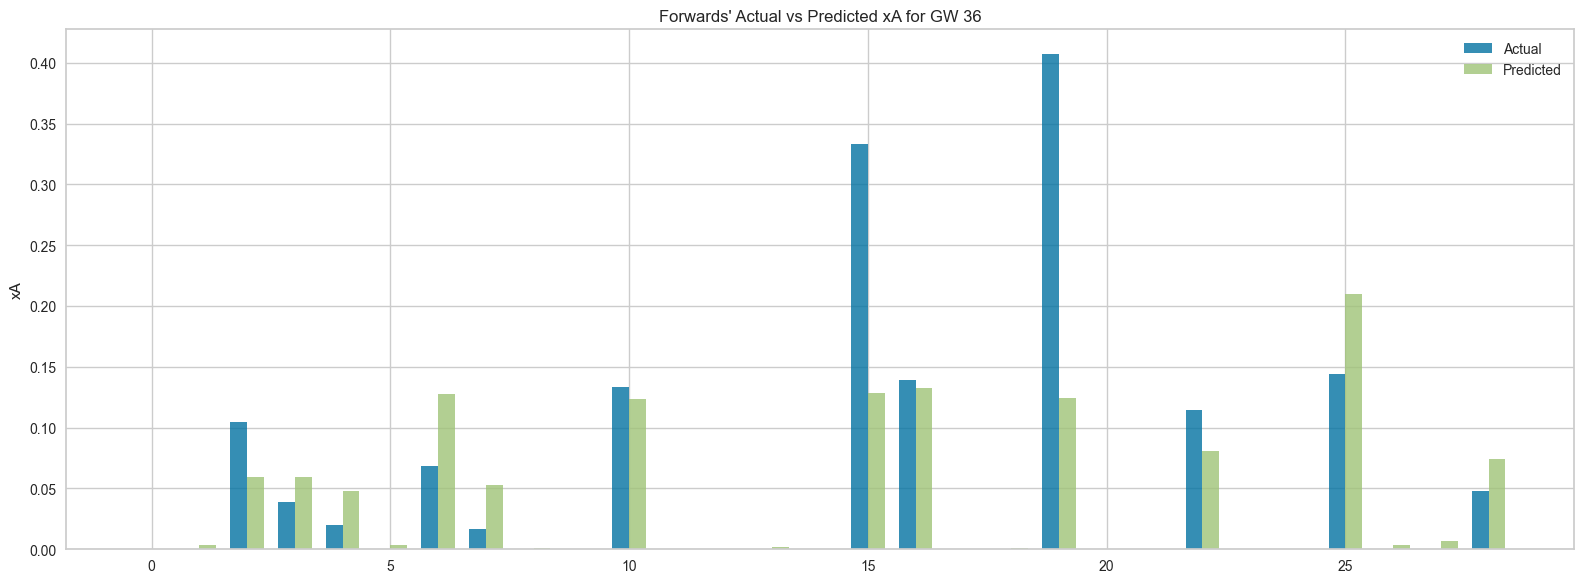

In [ ]:
# data_36_fwd_xa.reset_index(drop=True, inplace=True)
fwd_xa = data_36_fwd_xa[['xA']].copy()
data_36_fwd_xa.drop(columns=['position', 'xA'], inplace=True)

fwd_xa_preds_36 = predict_model(fwd_xa_model, data=data_36_fwd_xa)
fwd_xa_preds_36 = fwd_xa_preds_36.rename(columns={'prediction_label': 'xA_preds_trans'})

actual = fwd_xa['xA']
predicted = pt_fwd_xa.inverse_transform(fwd_xa_preds_36[['xA_preds_trans']].rename(columns={'xA_preds_trans': 'xA'}))

# Add predicted to data_36_fwd
data_36_fwd['xA_preds'] = predicted

# Bar plot side-by-side
x = np.arange(len(actual))
width = 0.35

# print
plt.figure(figsize=(16, 6))
plt.bar(x - width/2, actual, width, label='Actual', alpha=0.8)
plt.bar(x + width/2, predicted.flatten(), width, label='Predicted', alpha=0.8)

# plt.xticks(x, players, rotation=90)
plt.ylabel('xA')
plt.title("Forwards' Actual vs Predicted xA for GW 36")
plt.legend()
plt.tight_layout()
plt.show()


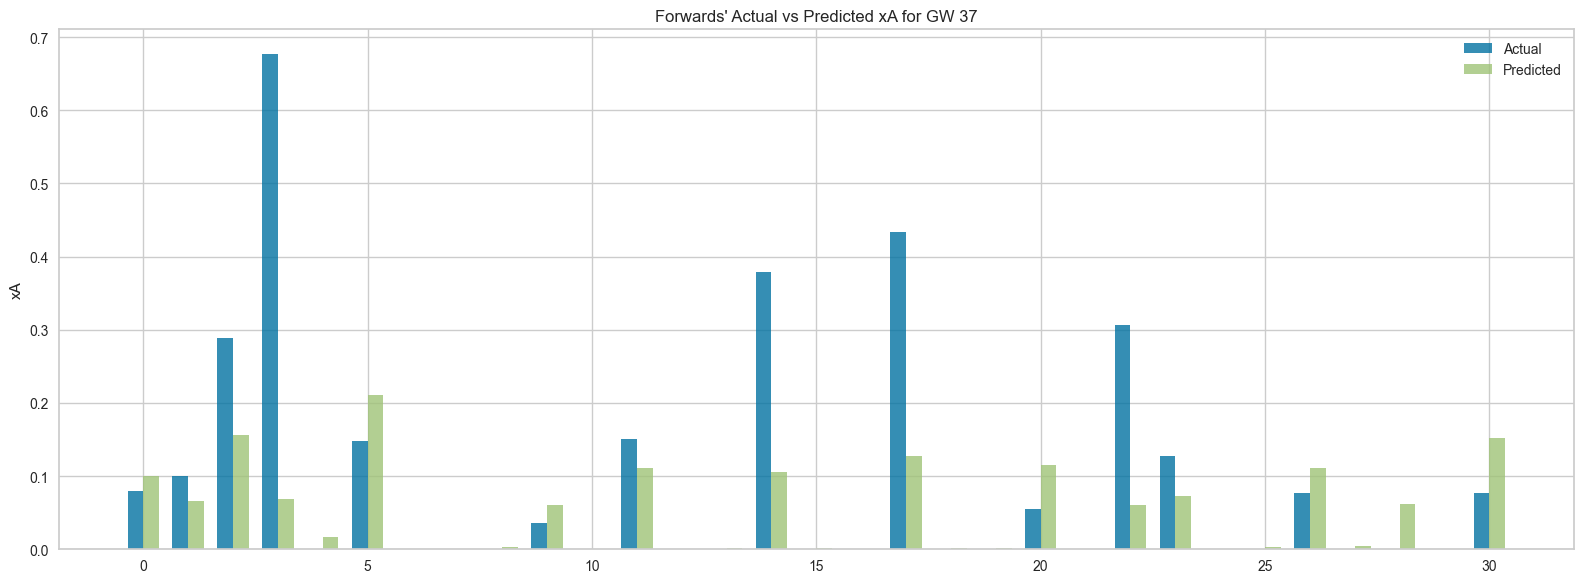

In [ ]:
# data_37_fwd_xa.reset_index(drop=True, inplace=True)
fwd_xa = data_37_fwd_xa[['xA']].copy()
data_37_fwd_xa.drop(columns=['position', 'xA'], inplace=True)

fwd_xa_preds_37 = predict_model(fwd_xa_model, data=data_37_fwd_xa)
fwd_xa_preds_37 = fwd_xa_preds_37.rename(columns={'prediction_label': 'xA_preds_trans'})

actual = fwd_xa['xA']
predicted = pt_fwd_xa.inverse_transform(fwd_xa_preds_37[['xA_preds_trans']].rename(columns={'xA_preds_trans': 'xA'}))

# Add predicted to data_37_fwd
data_37_fwd['xA_preds'] = predicted

# Bar plot side-by-side
x = np.arange(len(actual))
width = 0.35

# print
plt.figure(figsize=(16, 6))
plt.bar(x - width/2, actual, width, label='Actual', alpha=0.8)
plt.bar(x + width/2, predicted.flatten(), width, label='Predicted', alpha=0.8)

# plt.xticks(x, players, rotation=90)
plt.ylabel('xA')
plt.title("Forwards' Actual vs Predicted xA for GW 37")
plt.legend()
plt.tight_layout()
plt.show()


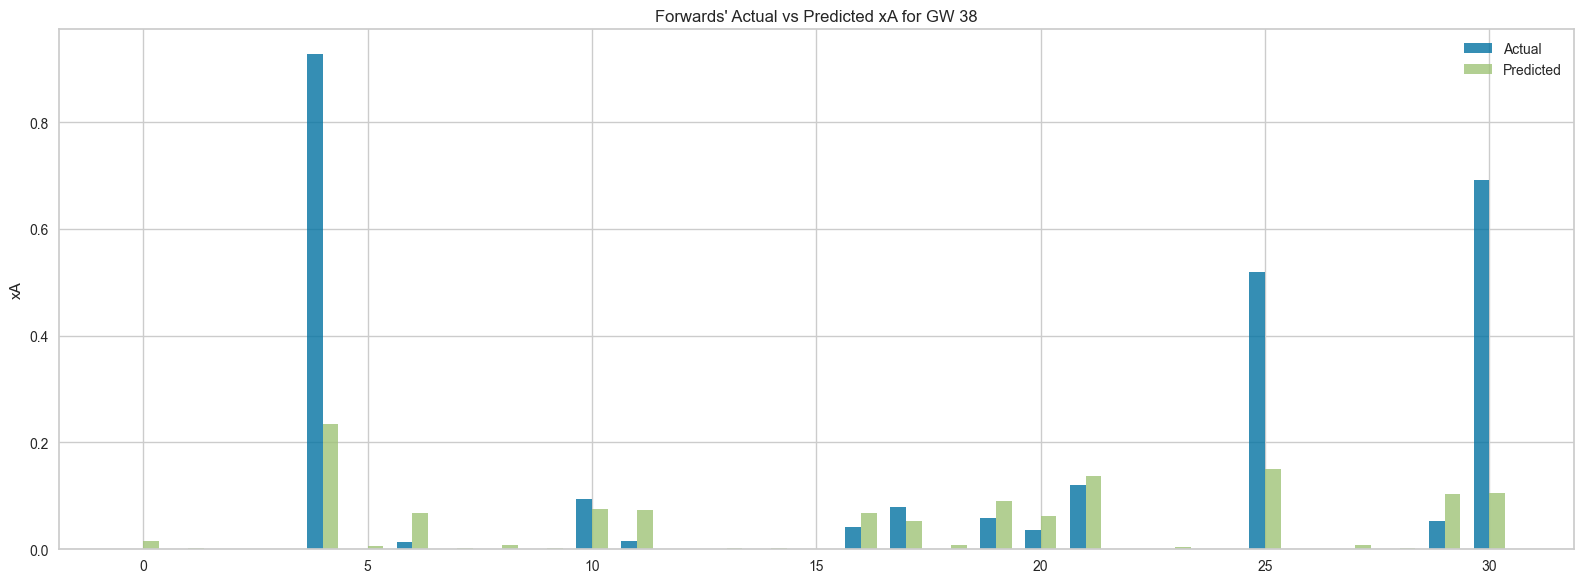

In [ ]:
# data_38_fwd_xa.reset_index(drop=True, inplace=True)
fwd_xa = data_38_fwd_xa[['xA']].copy()
data_38_fwd_xa.drop(columns=['position', 'xA'], inplace=True)

fwd_xa_preds_38 = predict_model(fwd_xa_model, data=data_38_fwd_xa)
fwd_xa_preds_38 = fwd_xa_preds_38.rename(columns={'prediction_label': 'xA_preds_trans'})

actual = fwd_xa['xA']
predicted = pt_fwd_xa.inverse_transform(fwd_xa_preds_38[['xA_preds_trans']].rename(columns={'xA_preds_trans': 'xA'}))

# Add predicted to data_38_fwd
data_38_fwd['xA_preds'] = predicted

# Bar plot side-by-side
x = np.arange(len(actual))
width = 0.35

# print
plt.figure(figsize=(16, 6))
plt.bar(x - width/2, actual, width, label='Actual', alpha=0.8)
plt.bar(x + width/2, predicted.flatten(), width, label='Predicted', alpha=0.8)

# plt.xticks(x, players, rotation=90)
plt.ylabel('xA')
plt.title("Forwards' Actual vs Predicted xA for GW 38")
plt.legend()
plt.tight_layout()
plt.show()


# Saves


In [ ]:
saves_features = ['position', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers',
            'saves',  'ict_index', 'influence', 'creativity', 'threat',

            'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1',  'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',


            'clean_sheets_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'clean_sheets_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5',  'xGChain_5', 'xGBuildup_5',  'xP_5'
                        ]

## GK


In [ ]:
data_36_gk_saves = data_36_gk[saves_features]
data_37_gk_saves = data_37_gk[saves_features]
data_38_gk_saves = data_38_gk[saves_features]

# Load model
gk_saves_model = load_model('../g_saves_final_model')
pt_gk_saves = joblib.load('../pt_gk_saves.pkl')  # Load fitted transformer

Transformation Pipeline and Model Successfully Loaded


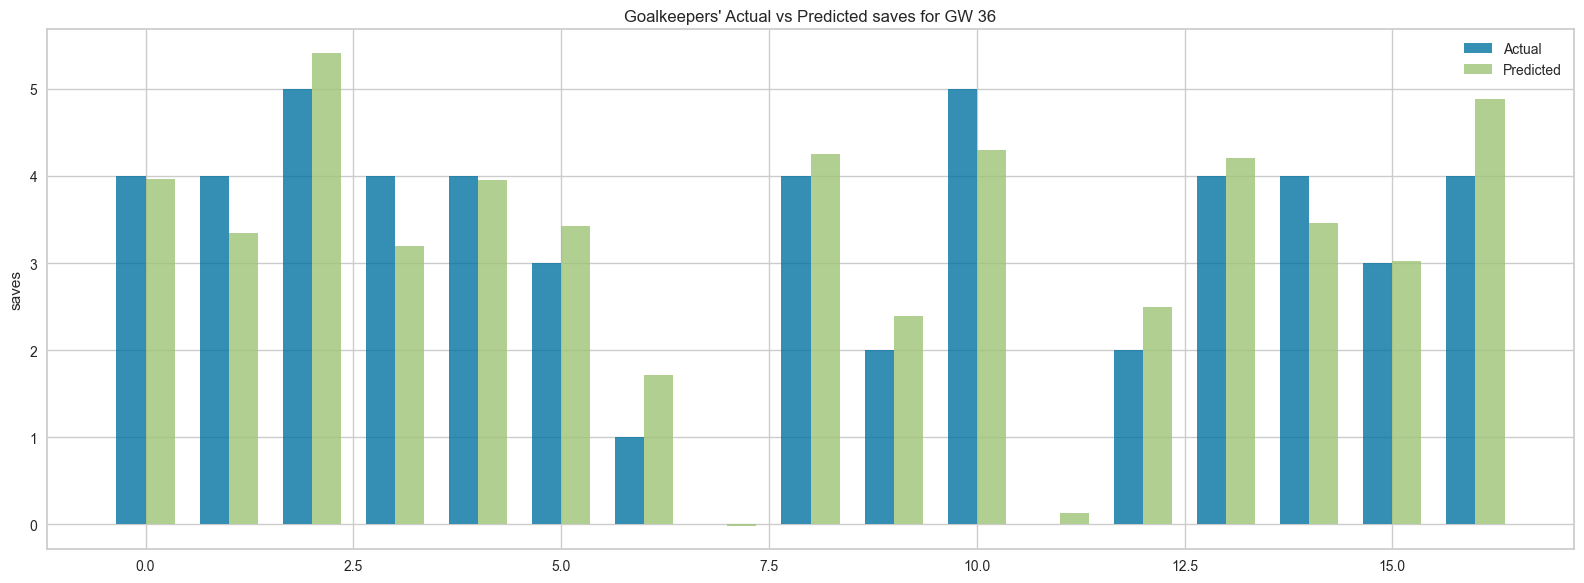

In [ ]:
# data_36_gk_saves.reset_index(drop=True, inplace=True)
gk_saves = data_36_gk_saves[['saves']].copy()
data_36_gk_saves.drop(columns=['position', 'saves'], inplace=True)

gk_saves_preds_36 = predict_model(gk_saves_model, data=data_36_gk_saves)
gk_saves_preds_36 = gk_saves_preds_36.rename(columns={'prediction_label': 'saves_preds_trans'})

actual = gk_saves['saves']
predicted = pt_gk_saves.inverse_transform(gk_saves_preds_36[['saves_preds_trans']].rename(columns={'saves_preds_trans': 'saves'}))

# Add predicted to data_36_gk
data_36_gk['saves_preds'] = predicted

# Bar plot side-by-side
x = np.arange(len(actual))
width = 0.35

# print
plt.figure(figsize=(16, 6))
plt.bar(x - width/2, actual, width, label='Actual', alpha=0.8)
plt.bar(x + width/2, predicted.flatten(), width, label='Predicted', alpha=0.8)

# plt.xticks(x, players, rotation=90)
plt.ylabel('saves')
plt.title("Goalkeepers' Actual vs Predicted saves for GW 36")
plt.legend()
plt.tight_layout()
plt.show()


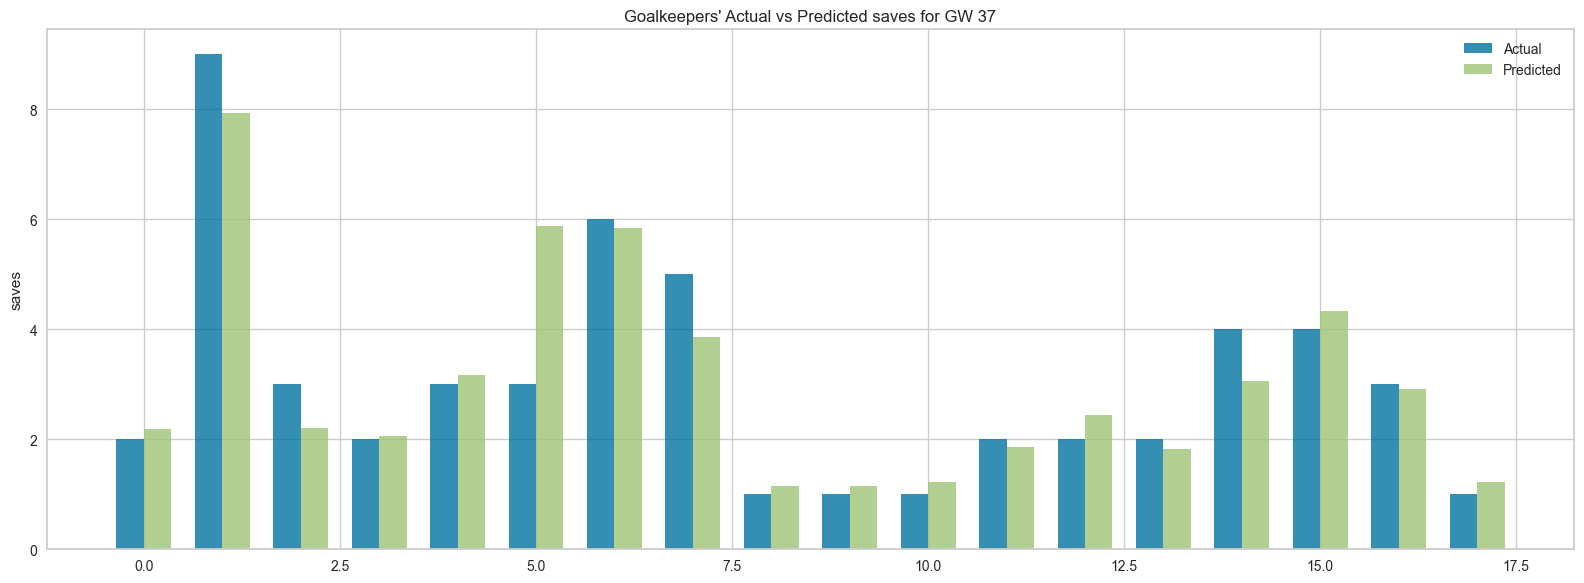

In [ ]:
# data_37_gk_saves.reset_index(drop=True, inplace=True)
gk_saves = data_37_gk_saves[['saves']].copy()
data_37_gk_saves.drop(columns=['position', 'saves'], inplace=True)

gk_saves_preds_37 = predict_model(gk_saves_model, data=data_37_gk_saves)
gk_saves_preds_37 = gk_saves_preds_37.rename(columns={'prediction_label': 'saves_preds_trans'})

actual = gk_saves['saves']
predicted = pt_gk_saves.inverse_transform(gk_saves_preds_37[['saves_preds_trans']].rename(columns={'saves_preds_trans': 'saves'}))

# Add predicted to data_37_gk
data_37_gk['saves_preds'] = predicted

# Bar plot side-by-side
x = np.arange(len(actual))
width = 0.35

# print
plt.figure(figsize=(16, 6))
plt.bar(x - width/2, actual, width, label='Actual', alpha=0.8)
plt.bar(x + width/2, predicted.flatten(), width, label='Predicted', alpha=0.8)

# plt.xticks(x, players, rotation=90)
plt.ylabel('saves')
plt.title("Goalkeepers' Actual vs Predicted saves for GW 37")
plt.legend()
plt.tight_layout()
plt.show()


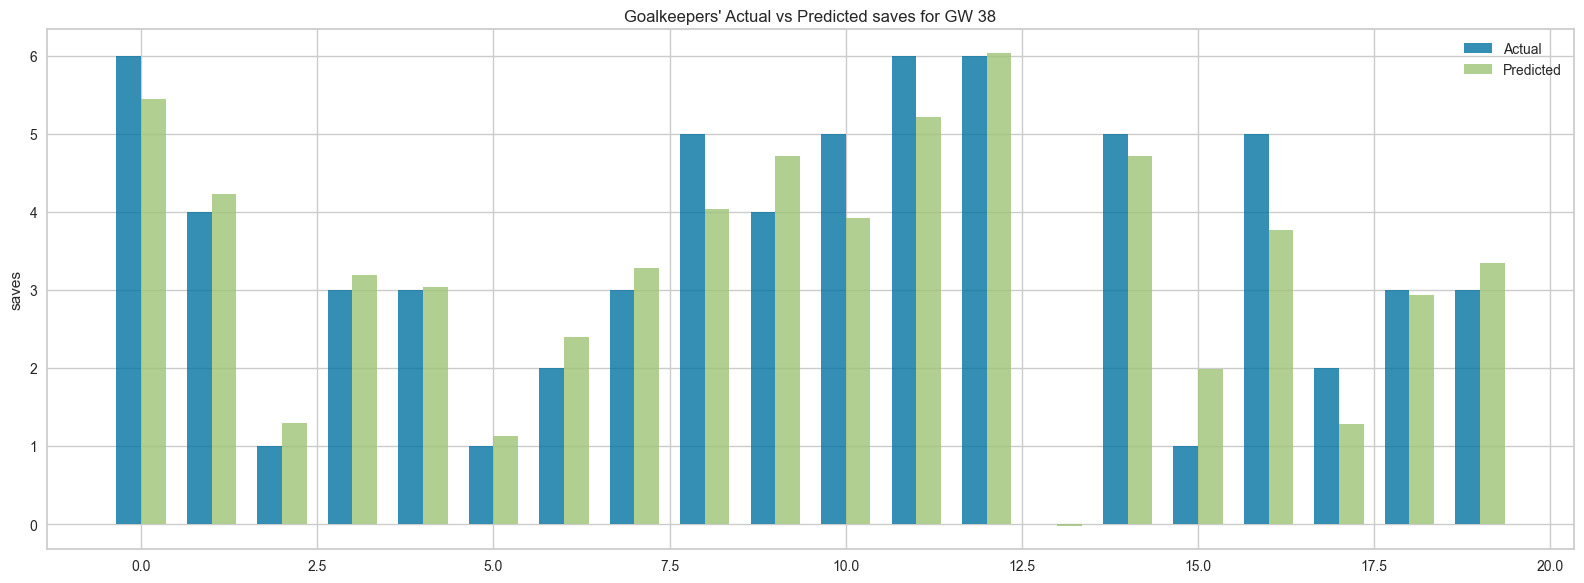

In [ ]:
# data_38_gk_saves.reset_index(drop=True, inplace=True)
gk_saves = data_38_gk_saves[['saves']].copy()
data_38_gk_saves.drop(columns=['position', 'saves'], inplace=True)

gk_saves_preds_38 = predict_model(gk_saves_model, data=data_38_gk_saves)
gk_saves_preds_38 = gk_saves_preds_38.rename(columns={'prediction_label': 'saves_preds_trans'})

actual = gk_saves['saves']
predicted = pt_gk_saves.inverse_transform(gk_saves_preds_38[['saves_preds_trans']].rename(columns={'saves_preds_trans': 'saves'}))

# Add predicted to data_38_gk
data_38_gk['saves_preds'] = predicted

# Bar plot side-by-side
x = np.arange(len(actual))
width = 0.35

# print
plt.figure(figsize=(16, 6))
plt.bar(x - width/2, actual, width, label='Actual', alpha=0.8)
plt.bar(x + width/2, predicted.flatten(), width, label='Predicted', alpha=0.8)

# plt.xticks(x, players, rotation=90)
plt.ylabel('saves')
plt.title("Goalkeepers' Actual vs Predicted saves for GW 38")
plt.legend()
plt.tight_layout()
plt.show()


# XGC


In [ ]:
xgc_features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty',  'ownership_change', 'percenatge_net_transfers',

            'expected_goals_conceded',  'ict_index', 'influence', 'creativity', 'threat',

            'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1', 'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

            'clean_sheets_3',  'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_saved_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',


            'clean_sheets_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_saved_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5',  'xGChain_5', 'xGBuildup_5',  'xP_5'
                        ]

## GK


In [ ]:
data_36_gk_xgc = data_36_gk[xgc_features]
data_37_gk_xgc = data_37_gk[xgc_features]
data_38_gk_xgc = data_38_gk[xgc_features]

# Load model
gk_xgc_model = load_model('../g_xgc_final_model')
pt_gk_xgc = joblib.load('../pt_gk_xgc.pkl')  # Load fitted transformer


Transformation Pipeline and Model Successfully Loaded


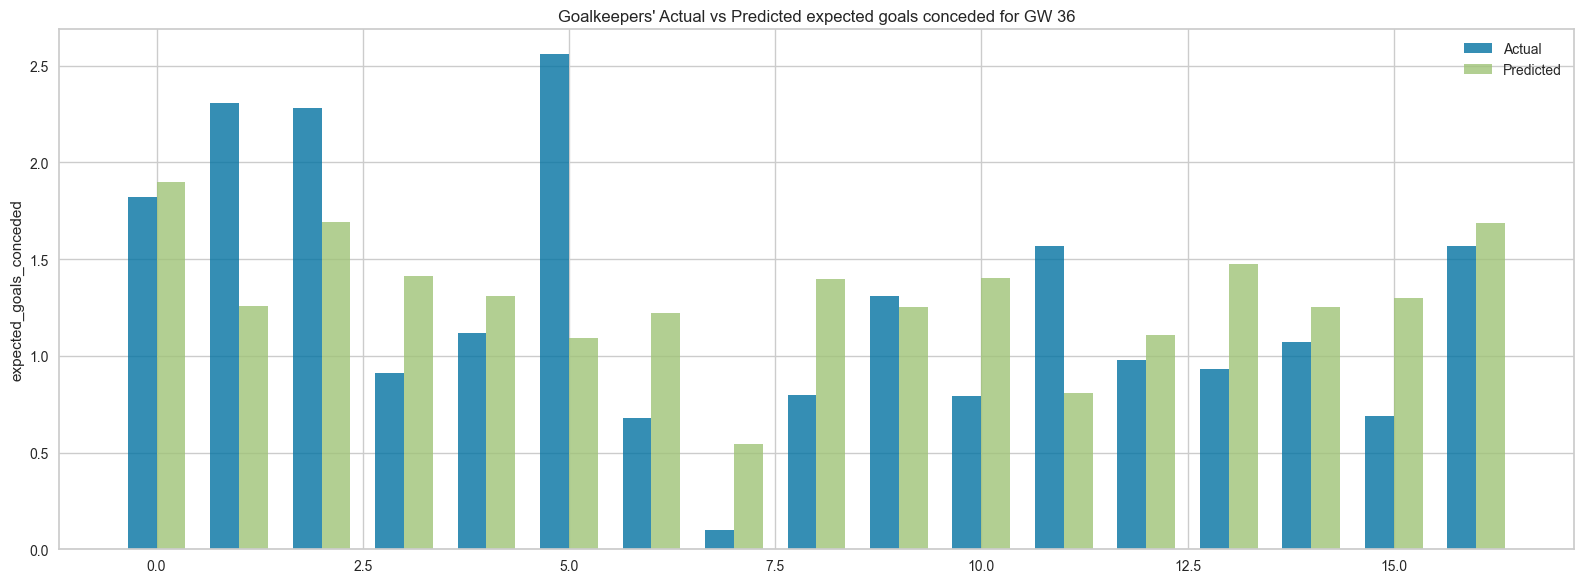

In [ ]:
# data_36_gk_xgc.reset_index(drop=True, inplace=True)
gk_xgc = data_36_gk_xgc[['expected_goals_conceded']].copy()
data_36_gk_xgc.drop(columns=['position', 'expected_goals_conceded'], inplace=True)

gk_xgc_preds_36 = predict_model(gk_xgc_model, data=data_36_gk_xgc)
gk_xgc_preds_36 = gk_xgc_preds_36.rename(columns={'prediction_label': 'xgc_preds_trans'})

actual = gk_xgc['expected_goals_conceded']
predicted = pt_gk_xgc.inverse_transform(gk_xgc_preds_36[['xgc_preds_trans']].rename(columns={'xgc_preds_trans': 'expected_goals_conceded'}))

# Add predicted to data_36_gk
data_36_gk['xgc_preds'] = predicted

# Bar plot side-by-side
x = np.arange(len(actual))
width = 0.35

# print
plt.figure(figsize=(16, 6))
plt.bar(x - width/2, actual, width, label='Actual', alpha=0.8)
plt.bar(x + width/2, predicted.flatten(), width, label='Predicted', alpha=0.8)

# plt.xticks(x, players, rotation=90)
plt.ylabel('expected_goals_conceded')
plt.title("Goalkeepers' Actual vs Predicted expected goals conceded for GW 36")
plt.legend()
plt.tight_layout()
plt.show()


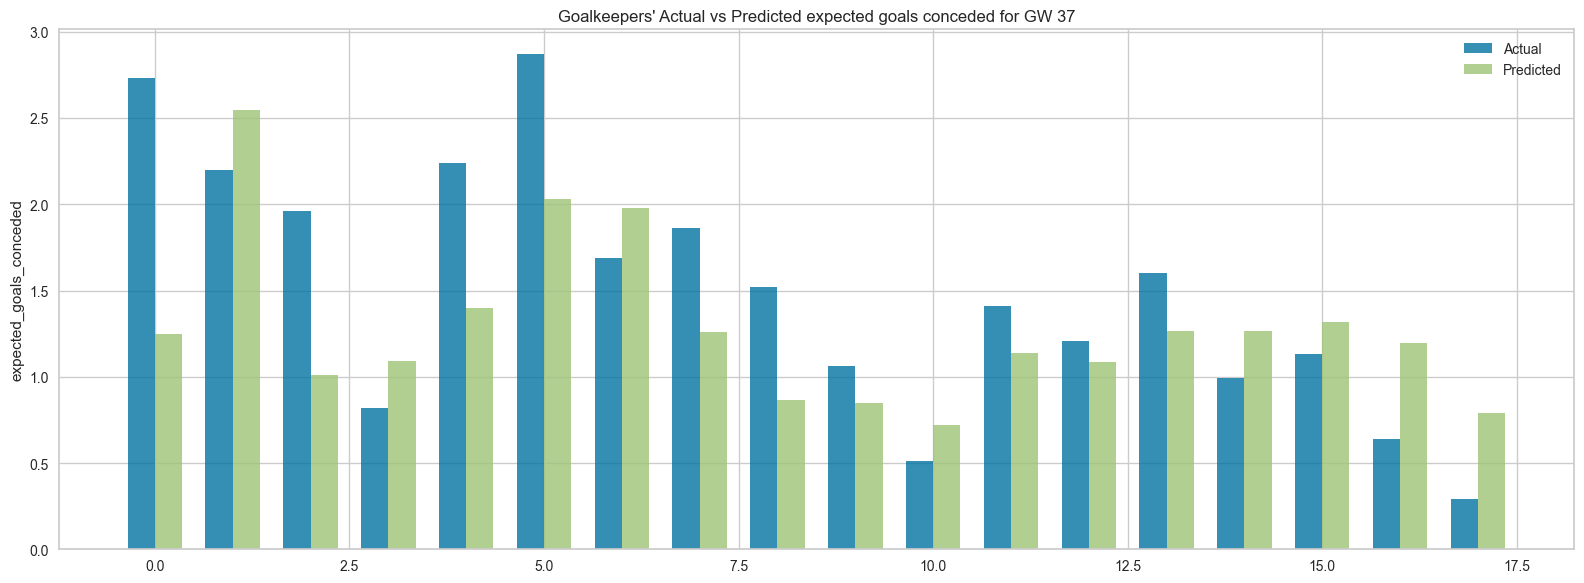

In [ ]:
# data_37_gk_xgc.reset_index(drop=True, inplace=True)
gk_xgc = data_37_gk_xgc[['expected_goals_conceded']].copy()
data_37_gk_xgc.drop(columns=['position', 'expected_goals_conceded'], inplace=True)

gk_xgc_preds_37 = predict_model(gk_xgc_model, data=data_37_gk_xgc)
gk_xgc_preds_37 = gk_xgc_preds_37.rename(columns={'prediction_label': 'xgc_preds_trans'})

actual = gk_xgc['expected_goals_conceded']
predicted = pt_gk_xgc.inverse_transform(gk_xgc_preds_37[['xgc_preds_trans']].rename(columns={'xgc_preds_trans': 'expected_goals_conceded'}))

# Add predicted to data_37_gk
data_37_gk['xgc_preds'] = predicted

# Bar plot side-by-side
x = np.arange(len(actual))
width = 0.35

# print
plt.figure(figsize=(16, 6))
plt.bar(x - width/2, actual, width, label='Actual', alpha=0.8)
plt.bar(x + width/2, predicted.flatten(), width, label='Predicted', alpha=0.8)

# plt.xticks(x, players, rotation=90)
plt.ylabel('expected_goals_conceded')
plt.title("Goalkeepers' Actual vs Predicted expected goals conceded for GW 37")
plt.legend()
plt.tight_layout()
plt.show()


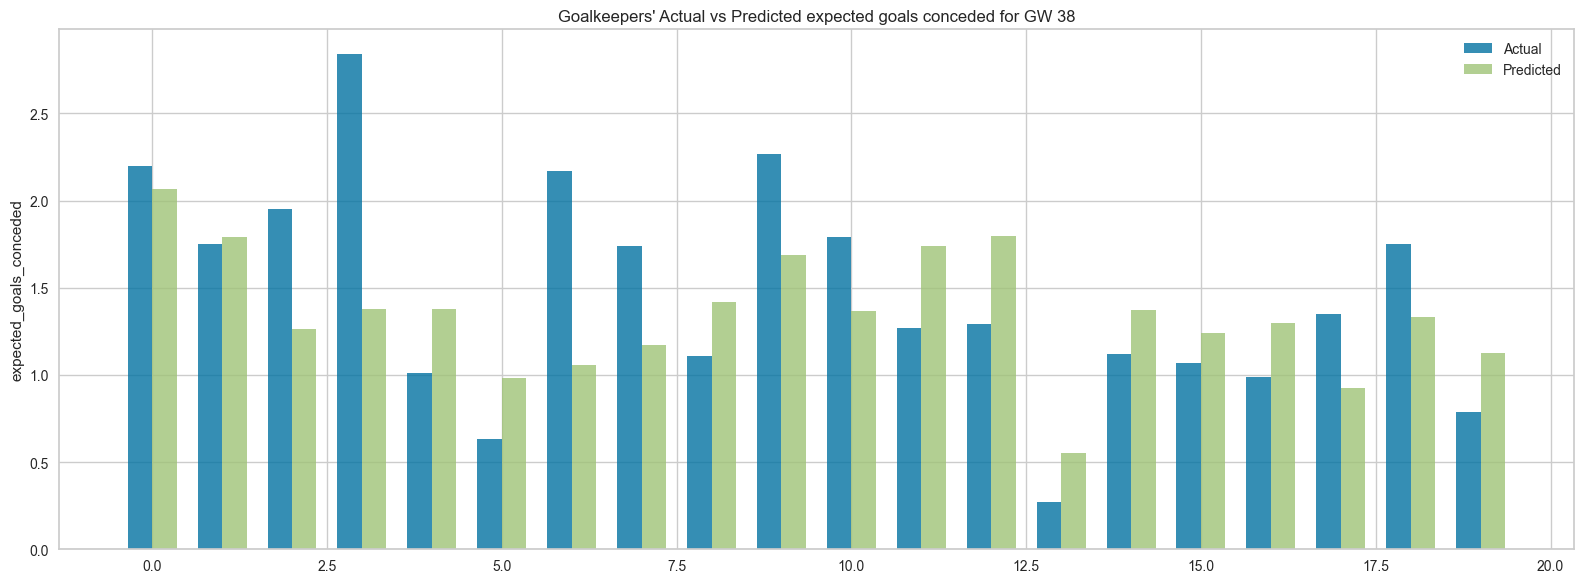

In [ ]:
# data_38_gk_xgc.reset_index(drop=True, inplace=True)
gk_xgc = data_38_gk_xgc[['expected_goals_conceded']].copy()
data_38_gk_xgc.drop(columns=['position', 'expected_goals_conceded'], inplace=True)

gk_xgc_preds_38 = predict_model(gk_xgc_model, data=data_38_gk_xgc)
gk_xgc_preds_38 = gk_xgc_preds_38.rename(columns={'prediction_label': 'xgc_preds_trans'})

actual = gk_xgc['expected_goals_conceded']
predicted = pt_gk_xgc.inverse_transform(gk_xgc_preds_38[['xgc_preds_trans']].rename(columns={'xgc_preds_trans': 'expected_goals_conceded'}))

# Add predicted to data_38_gk
data_38_gk['xgc_preds'] = predicted

# Bar plot side-by-side
x = np.arange(len(actual))
width = 0.35

# print
plt.figure(figsize=(16, 6))
plt.bar(x - width/2, actual, width, label='Actual', alpha=0.8)
plt.bar(x + width/2, predicted.flatten(), width, label='Predicted', alpha=0.8)

# plt.xticks(x, players, rotation=90)
plt.ylabel('expected_goals_conceded')
plt.title("Goalkeepers' Actual vs Predicted expected goals conceded for GW 38")
plt.legend()
plt.tight_layout()
plt.show()


## DEF


In [ ]:
data_36_def_xgc = data_36_def[xgc_features]
data_37_def_xgc = data_37_def[xgc_features]
data_38_def_xgc = data_38_def[xgc_features]

# Load model
def_xgc_model = load_model('../def_xgc_final_model')
pt_def_xgc = joblib.load('../pt_def_xgc.pkl')  # Load fitted transformer

Transformation Pipeline and Model Successfully Loaded


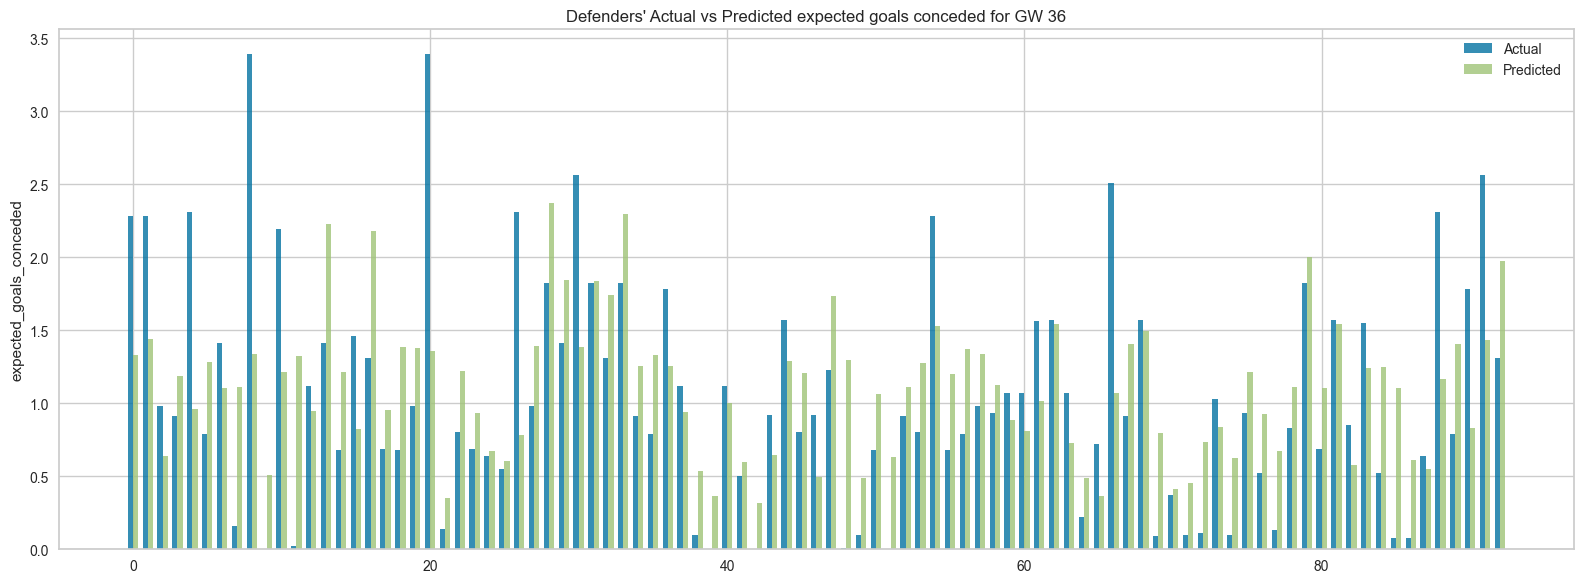

In [ ]:
# data_36_def_xgc.reset_index(drop=True, inplace=True)
def_xgc = data_36_def_xgc[['expected_goals_conceded']].copy()
data_36_def_xgc.drop(columns=['position', 'expected_goals_conceded'], inplace=True)

def_xgc_preds_36 = predict_model(def_xgc_model, data=data_36_def_xgc)
def_xgc_preds_36 = def_xgc_preds_36.rename(columns={'prediction_label': 'xgc_preds_trans'})

actual = def_xgc['expected_goals_conceded']
predicted = pt_def_xgc.inverse_transform(def_xgc_preds_36[['xgc_preds_trans']].rename(columns={'xgc_preds_trans': 'expected_goals_conceded'}))

# Add predicted to data_36_def
data_36_def['xgc_preds'] = predicted

# Bar plot side-by-side
x = np.arange(len(actual))
width = 0.35

# print
plt.figure(figsize=(16, 6))
plt.bar(x - width/2, actual, width, label='Actual', alpha=0.8)
plt.bar(x + width/2, predicted.flatten(), width, label='Predicted', alpha=0.8)

# plt.xticks(x, players, rotation=90)
plt.ylabel('expected_goals_conceded')
plt.title("Defenders' Actual vs Predicted expected goals conceded for GW 36")
plt.legend()
plt.tight_layout()
plt.show()


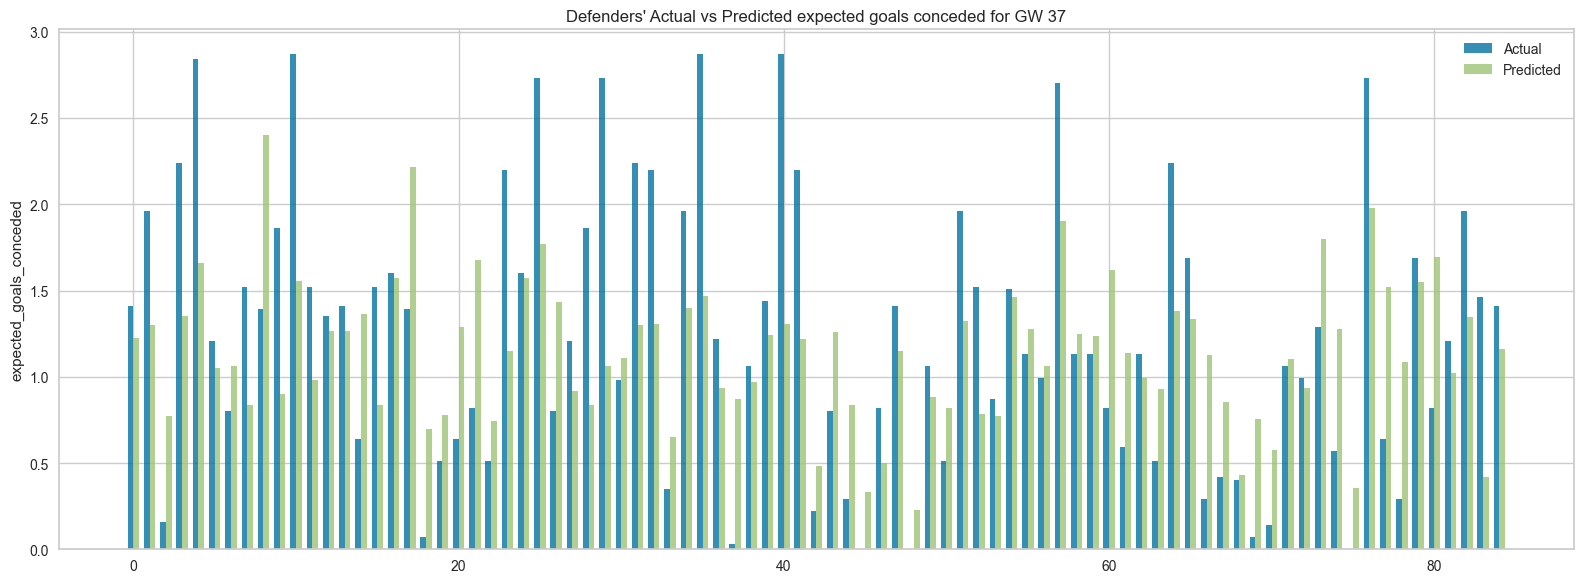

In [ ]:
# data_37_def_xgc.reset_index(drop=True, inplace=True)
def_xgc = data_37_def_xgc[['expected_goals_conceded']].copy()
data_37_def_xgc.drop(columns=['position', 'expected_goals_conceded'], inplace=True)

def_xgc_preds_37 = predict_model(def_xgc_model, data=data_37_def_xgc)
def_xgc_preds_37 = def_xgc_preds_37.rename(columns={'prediction_label': 'xgc_preds_trans'})

actual = def_xgc['expected_goals_conceded']
predicted = pt_def_xgc.inverse_transform(def_xgc_preds_37[['xgc_preds_trans']].rename(columns={'xgc_preds_trans': 'expected_goals_conceded'}))

# Add predicted to data_37_def
data_37_def['xgc_preds'] = predicted

# Bar plot side-by-side
x = np.arange(len(actual))
width = 0.35

# print
plt.figure(figsize=(16, 6))
plt.bar(x - width/2, actual, width, label='Actual', alpha=0.8)
plt.bar(x + width/2, predicted.flatten(), width, label='Predicted', alpha=0.8)

# plt.xticks(x, players, rotation=90)
plt.ylabel('expected_goals_conceded')
plt.title("Defenders' Actual vs Predicted expected goals conceded for GW 37")
plt.legend()
plt.tight_layout()
plt.show()


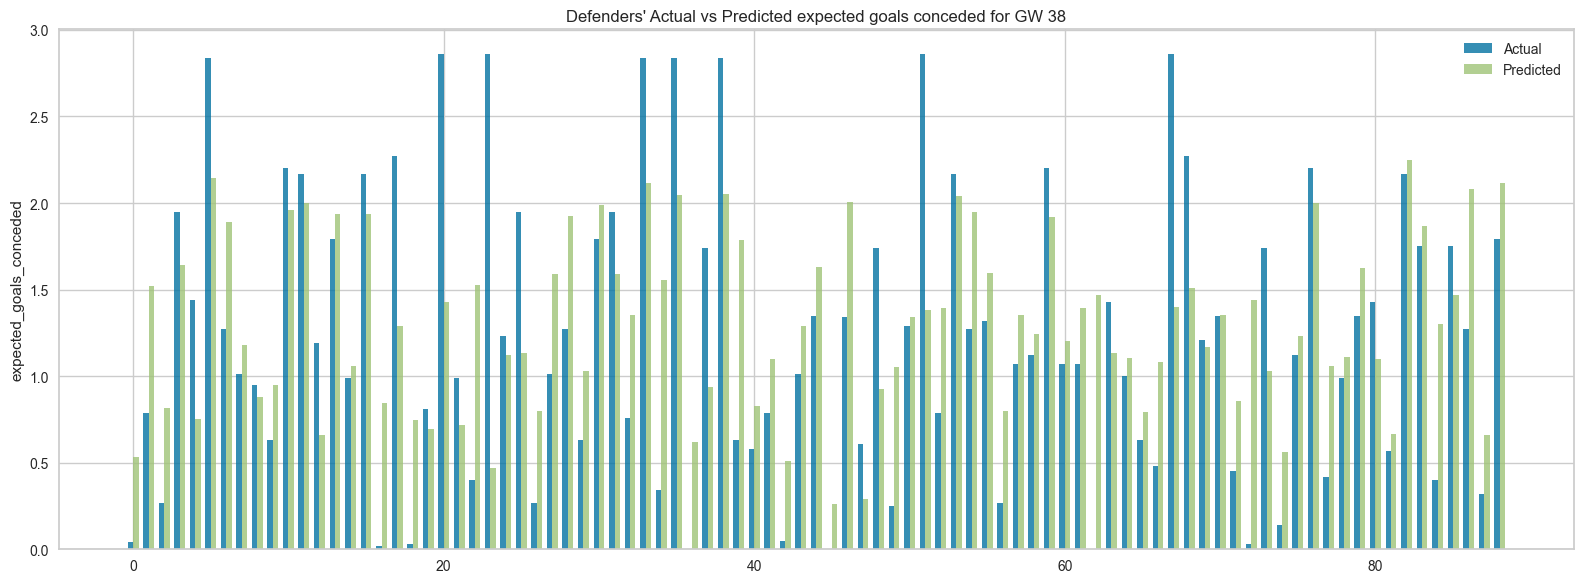

In [ ]:
# data_38_def_xgc.reset_index(drop=True, inplace=True)
def_xgc = data_38_def_xgc[['expected_goals_conceded']].copy()
data_38_def_xgc.drop(columns=['position', 'expected_goals_conceded'], inplace=True)

def_xgc_preds_38 = predict_model(def_xgc_model, data=data_38_def_xgc)
def_xgc_preds_38 = def_xgc_preds_38.rename(columns={'prediction_label': 'xgc_preds_trans'})

actual = def_xgc['expected_goals_conceded']
predicted = pt_def_xgc.inverse_transform(def_xgc_preds_38[['xgc_preds_trans']].rename(columns={'xgc_preds_trans': 'expected_goals_conceded'}))

# Add predicted to data_38_def
data_38_def['xgc_preds'] = predicted

# Bar plot side-by-side
x = np.arange(len(actual))
width = 0.35

# print
plt.figure(figsize=(16, 6))
plt.bar(x - width/2, actual, width, label='Actual', alpha=0.8)
plt.bar(x + width/2, predicted.flatten(), width, label='Predicted', alpha=0.8)

# plt.xticks(x, players, rotation=90)
plt.ylabel('expected_goals_conceded')
plt.title("Defenders' Actual vs Predicted expected goals conceded for GW 38")
plt.legend()
plt.tight_layout()
plt.show()


# Combine Gw data predictions


In [ ]:
# Merge all the preds and sort by index
preds_36 = pd.concat([data_36_gk, data_36_def, data_36_mid, data_36_fwd]).sort_index()
cols_to_add = ['saves_preds', 'xgc_preds', 'xG_preds', 'xA_preds']

# Now add the columns to the gw_data
data_36[cols_to_add] = preds_36[cols_to_add]
data_36.to_csv('./data_36_with_preds.csv', index=True)

# Merge all the preds and sort by index
preds_37 = pd.concat([data_37_gk, data_37_def, data_37_mid, data_37_fwd]).sort_index()
cols_to_add = ['saves_preds', 'xgc_preds', 'xG_preds', 'xA_preds']

# Now add the columns to the gw_data
data_37[cols_to_add] = preds_37[cols_to_add]
data_37.to_csv('./data_37_with_preds.csv', index=True)

# Merge all the preds and sort by index
preds_38 = pd.concat([data_38_gk, data_38_def, data_38_mid, data_38_fwd]).sort_index()
cols_to_add = ['saves_preds', 'xgc_preds', 'xG_preds', 'xA_preds']

# Now add the columns to the gw_data
data_38[cols_to_add] = preds_38[cols_to_add]
data_38.to_csv('./data_38_with_preds.csv', index=True)